# Load packages

In [1]:
import scimap as sm

Running SCIMAP  2.1.1


/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/shiboken2/files.dir/shibokensupport/__feature__.py:142: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



In [2]:
import sys

import anndata as ad
import seaborn as sns; sns.set(color_codes=True)
import numpy as np

In [3]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
from scipy.stats import fisher_exact

# Load data

In [9]:
image_path = '/Volumes/Expansion/Auria/First_milestone_intermediate_files/Data_AllMarkers_filtered.csv'
# Convert the data to scimap format
adata = sm.pp.mcmicro_to_scimap(image_path, 
                                remove_dna=False, remove_string_from_name=None, log=False, drop_markers=None,
                                random_sample=None, unique_CellId=True, CellId='CellID', split='X_centroid',
                                custom_imageid=None, min_cells=None, output_dir=None)
adata.obsm['spatial'] = np.array(adata.obs[['Y_centroid', 'X_centroid']])
adata

Loading Data_AllMarkers_filtered.csv


/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/scimap/preprocessing/mcmicro_to_scimap.py:106: DtypeWarning:

Columns (33) have mixed types. Specify dtype option on import or set low_memory=False.



AnnData object with n_obs × n_vars = 3681772 × 25
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'celltype.1', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'celltype_2', 'CellID', 'imageid'
    uns: 'all_markers'
    obsm: 'spatial'

In [10]:
adata.obs

,X_centroid,Y_centroid,core_imageid,cores.x,celltype,Annotation,Stage,patient_id_AB19_1654,Area,Eccentricity,celltype.1,antioxidant_NQOI,antioxidant_GCLC,antioxidant_TXNRD1,antioxidant_GLUT1,NQO1_GCLC_VIM,celltype_2,CellID,imageid
19_02_02A_1,2027.642,1011.2380,core77_19_02_02A,core77,Other,Invasive border,2,AB19-1654_P10158,282,0.821700,Other,failed_classify,failed_classify,failed_classify,failed_classify,---,Other,1,19_02_02A
19_02_01A_10,5871.136,777.1124,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,258,0.620470,Tumor,NQO1_pos,failed_classify,TXNRD1_pos,failed_classify,+--,Tumor_+--,10,19_02_01A
19_02_02A_10,1999.424,1195.5040,core77_19_02_02A,core77,CD68.Macrophages,Invasive border,2,AB19-1654_P10158,125,0.755401,CD68.Macrophages,NQO1_pos,failed_classify,failed_classify,failed_classify,+--,CD68.Macrophages,10,19_02_02A
19_02_01A_100,6136.928,858.5450,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,222,0.803584,Tumor,NQO1_pos,failed_classify,TXNRD1_pos,failed_classify,+--,Tumor_+--,100,19_02_01A
19_02_02A_100,1728.540,1302.0830,core77_19_02_02A,core77,Immune,Invasive border,2,AB19-1654_P10158,300,0.522613,Immune,failed_classify,failed_classify,failed_classify,failed_classify,---,Immune,100,19_02_02A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INF1_99998,36889.410,6446.4120,core22_INF1,core22,Tumor,Inflammation,unknown,AB19-1654_P10648,148,0.641780,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,Tumor_---,99998,INF1
1B_99999,11181.530,7239.2680,core64_1B,core64,FOXP3.CD4.Tregs,Tumor center,2,AB19-1654_P10561,366,0.771436,FOXP3.CD4.Tregs,failed_classify,GCLC_pos,failed_classify,failed_classify,-++,FOXP3.CD4.Tregs,99999,1B
2B_99999,8371.249,6579.8230,core71_2B,core71,CD4.T.cells,Lymph node met,2,AB19-1654_P10599,558,0.863484,CD4.T.cells,failed_classify,GCLC_pos,failed_classify,failed_classify,-++,CD4.T.cells,99999,2B
3B_99999,20828.410,4477.0180,core42_3B,core42,Tumor,Tumor center,1,AB19-1654_P10620,112,0.883622,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,Tumor_---,99999,3B


In [11]:
adata.raw = adata

# Scimap

In [13]:
scimap_lag_adata = sm.tl.spatial_expression(adata, method='radius', radius=45, label='spatial_expression')

Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell


In [ ]:
scimap_lag_adata = sm.tl.spatial_cluster(scimap_lag_adata, df_name='spatial_expression', method='kmeans', k = 25, label='spatial_expression_kmeans')

Kmeans clustering


In [16]:
scimap_lag_adata.obs

,X_centroid,Y_centroid,core_imageid,cores.x,celltype,Annotation,Stage,patient_id_AB19_1654,Area,Eccentricity,celltype.1,antioxidant_NQOI,antioxidant_GCLC,antioxidant_TXNRD1,antioxidant_GLUT1,NQO1_GCLC_VIM,CellID,imageid,spatial_expression_kmeans
19_02_02A_1,2027.642,1011.2380,core77_19_02_02A,core77,Other,Invasive border,2,AB19-1654_P10158,282,0.821700,Other,failed_classify,failed_classify,failed_classify,failed_classify,---,1,19_02_02A,23
19_02_01A_10,5871.136,777.1124,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,258,0.620470,Tumor,NQO1_pos,failed_classify,TXNRD1_pos,failed_classify,+--,10,19_02_01A,24
19_02_02A_10,1999.424,1195.5040,core77_19_02_02A,core77,CD68.Macrophages,Invasive border,2,AB19-1654_P10158,125,0.755401,CD68.Macrophages,NQO1_pos,failed_classify,failed_classify,failed_classify,+--,10,19_02_02A,16
19_02_01A_100,6136.928,858.5450,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,222,0.803584,Tumor,NQO1_pos,failed_classify,TXNRD1_pos,failed_classify,+--,100,19_02_01A,24
19_02_02A_100,1728.540,1302.0830,core77_19_02_02A,core77,Immune,Invasive border,2,AB19-1654_P10158,300,0.522613,Immune,failed_classify,failed_classify,failed_classify,failed_classify,---,100,19_02_02A,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INF1_99998,36889.410,6446.4120,core22_INF1,core22,Tumor,Inflammation,unknown,AB19-1654_P10648,148,0.641780,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,99998,INF1,22
1B_99999,11181.530,7239.2680,core64_1B,core64,FOXP3.CD4.Tregs,Tumor center,2,AB19-1654_P10561,366,0.771436,FOXP3.CD4.Tregs,failed_classify,GCLC_pos,failed_classify,failed_classify,-++,99999,1B,11
2B_99999,8371.249,6579.8230,core71_2B,core71,CD4.T.cells,Lymph node met,2,AB19-1654_P10599,558,0.863484,CD4.T.cells,failed_classify,GCLC_pos,failed_classify,failed_classify,-++,99999,2B,1
3B_99999,20828.410,4477.0180,core42_3B,core42,Tumor,Tumor center,1,AB19-1654_P10620,112,0.883622,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,99999,3B,21


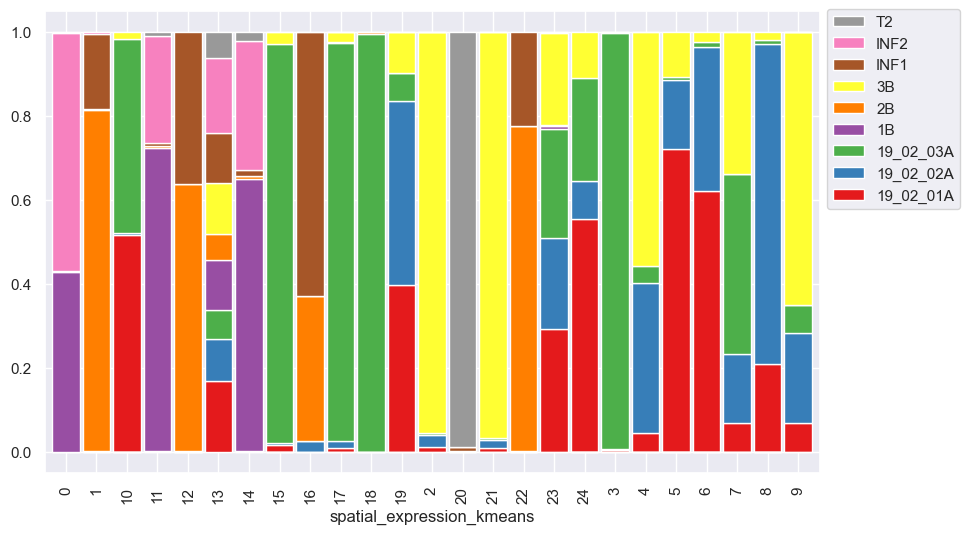

In [17]:
sm.pl.stacked_barplot (scimap_lag_adata, x_axis='spatial_expression_kmeans', y_axis='imageid', figsize=(10, 6))

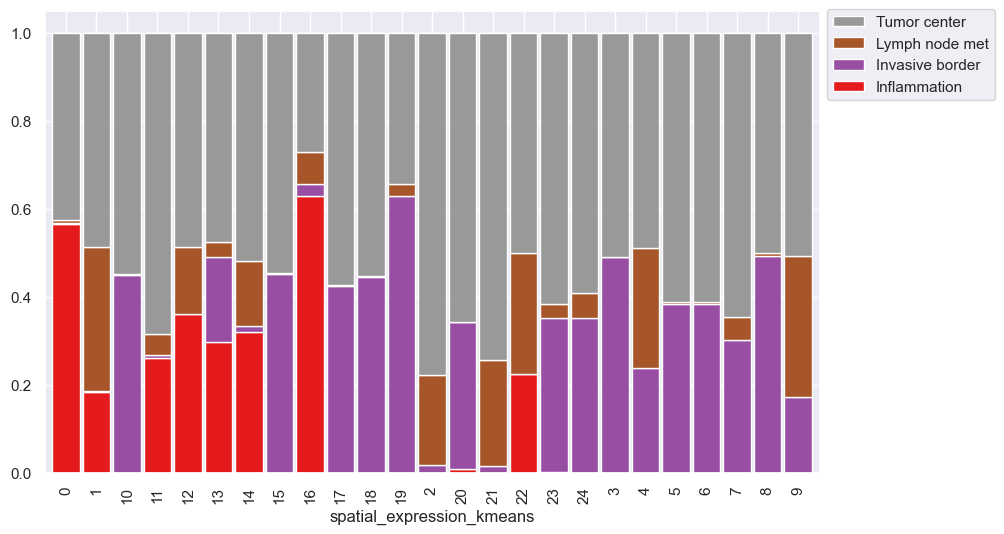

In [18]:
sm.pl.stacked_barplot (scimap_lag_adata, x_axis='spatial_expression_kmeans', y_axis='Annotation', figsize=(10, 6))

In [19]:
Scimap_adata = sm.tl.spatial_count(scimap_lag_adata, phenotype='celltype', method='radius', radius=45, label='spatial_count')
Scimap_adata = sm.tl.spatial_cluster(Scimap_adata, df_name='spatial_count', method='kmeans', k=25, label='spatial_count_kmeans')

Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Kmeans clustering


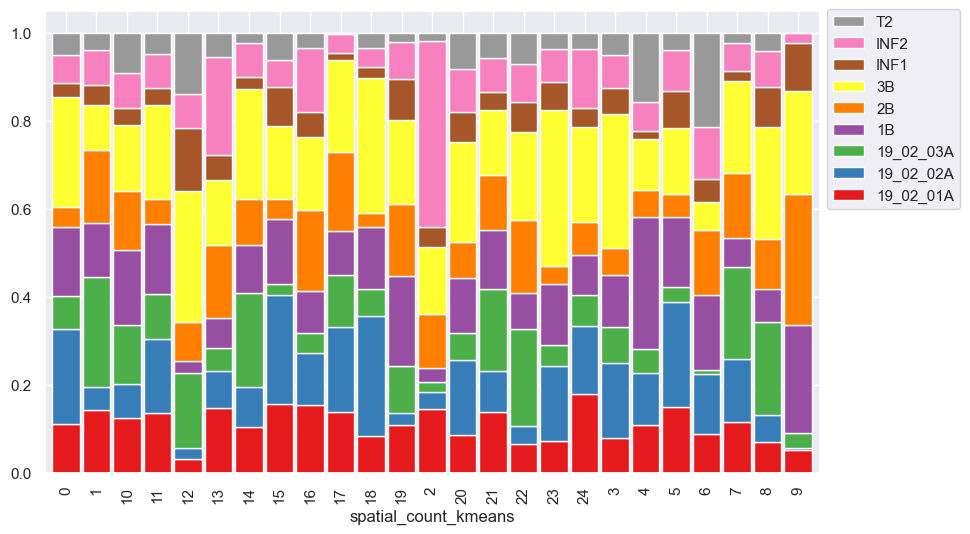

In [21]:
sm.pl.stacked_barplot (Scimap_adata, x_axis='spatial_count_kmeans', y_axis='imageid', figsize=(10, 6))

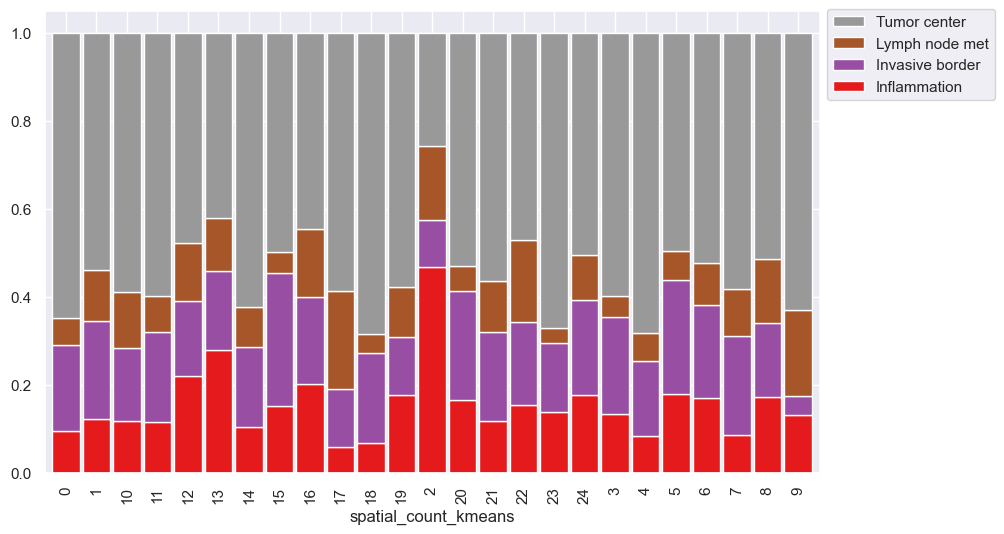

In [22]:
sm.pl.stacked_barplot (Scimap_adata, x_axis='spatial_count_kmeans', y_axis='Annotation', figsize=(10, 6))

# Spatial count based on celltype_2

In [12]:
adata

AnnData object with n_obs × n_vars = 3681772 × 25
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'celltype.1', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'celltype_2', 'CellID', 'imageid'
    uns: 'all_markers'
    obsm: 'spatial'

In [13]:
#Scimap_count_adata = sm.tl.spatial_count(adata, phenotype='NQO1_GCLC_VIM', method='radius', radius=45, label='spatial_count')
Scimap_count_adata = sm.tl.spatial_count(adata, phenotype='celltype_2', method='radius', radius=45, label='spatial_count_celltype2')

Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell


In [14]:
Scimap_count_adata = sm.tl.spatial_cluster(Scimap_count_adata, df_name='spatial_count_celltype2', method='kmeans', k=20, label='spatial_count_kmeans_celltype2')

Kmeans clustering


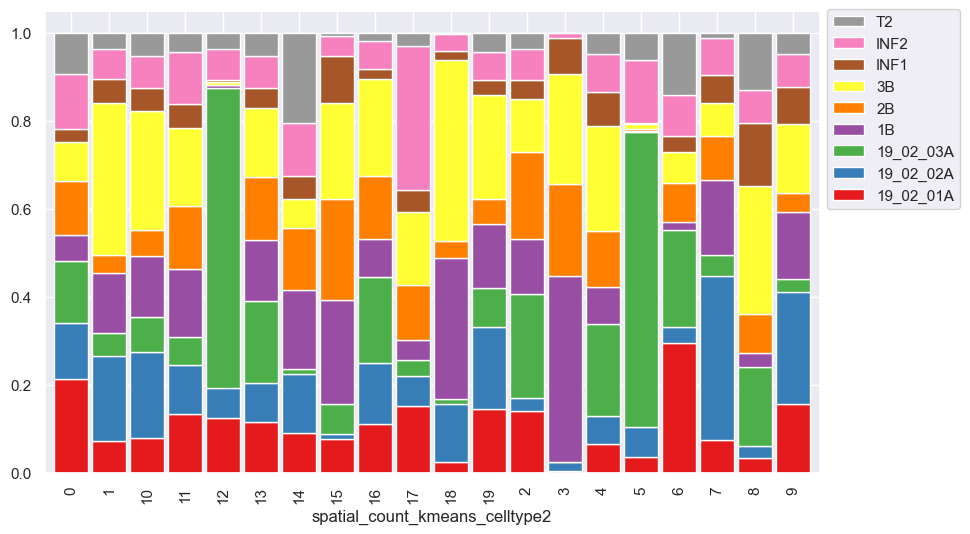

In [15]:
sm.pl.stacked_barplot (Scimap_count_adata, x_axis='spatial_count_kmeans_celltype2', y_axis='imageid', figsize=(10, 6))

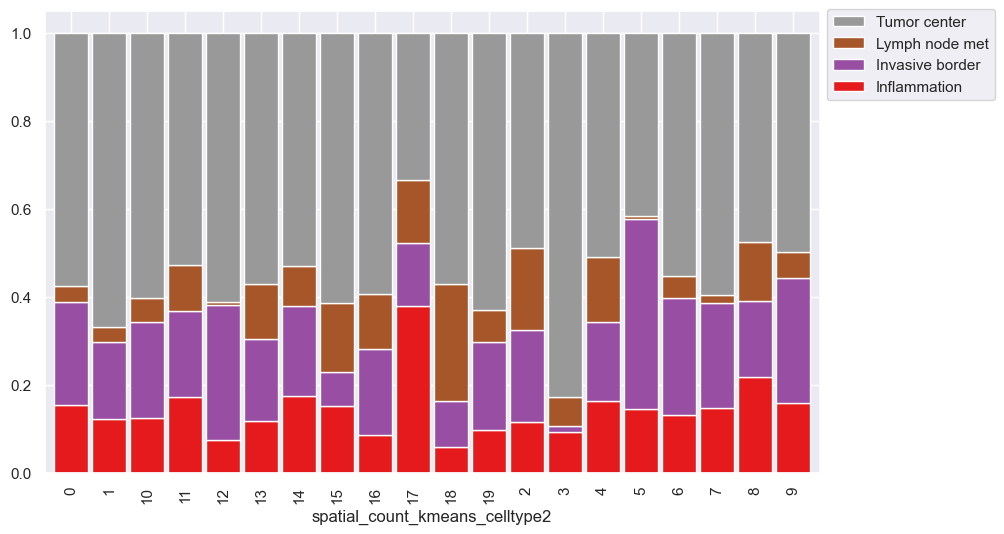

In [16]:
sm.pl.stacked_barplot (Scimap_count_adata, x_axis='spatial_count_kmeans_celltype2', y_axis='Annotation', figsize=(10, 6))

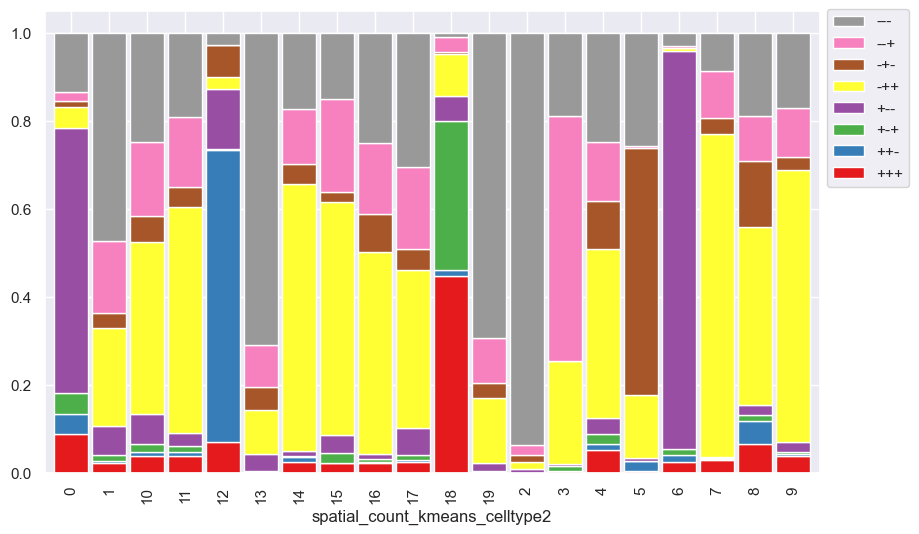

In [17]:
sm.pl.stacked_barplot (Scimap_count_adata, x_axis='spatial_count_kmeans_celltype2', y_axis='NQO1_GCLC_VIM', figsize=(10, 6))

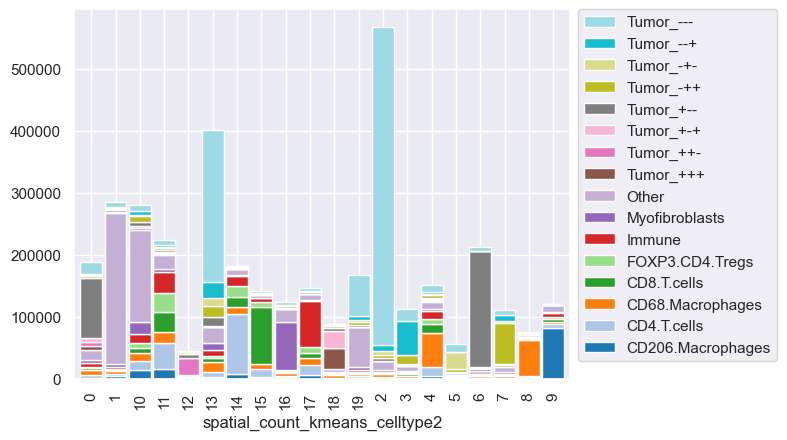

In [18]:
sm.pl.stacked_barplot (Scimap_count_adata,
                       x_axis='spatial_count_kmeans_celltype2',
                       y_axis='celltype_2',
                       method='absolute')

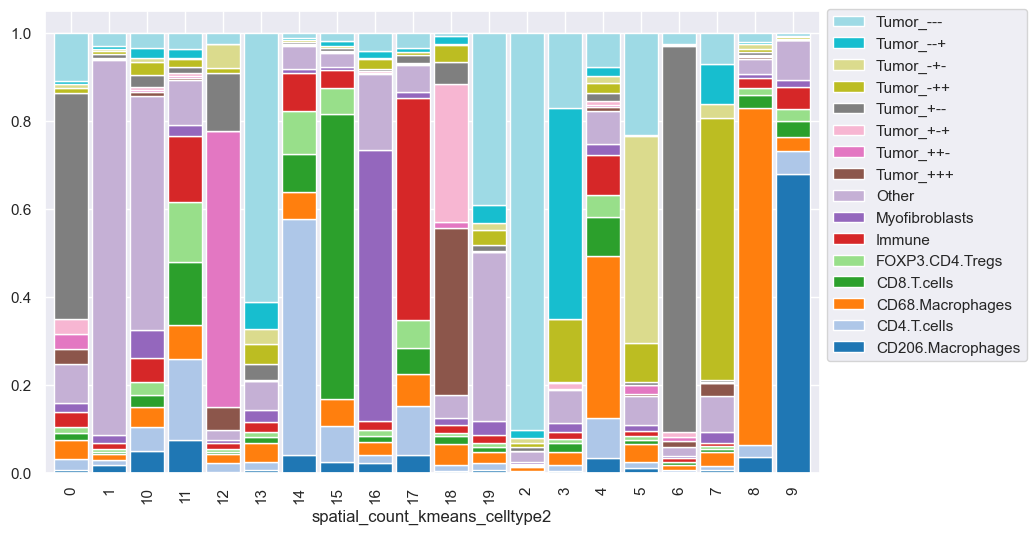

In [19]:
sm.pl.stacked_barplot (Scimap_count_adata, x_axis='spatial_count_kmeans_celltype2', y_axis='celltype_2', figsize=(10, 6))

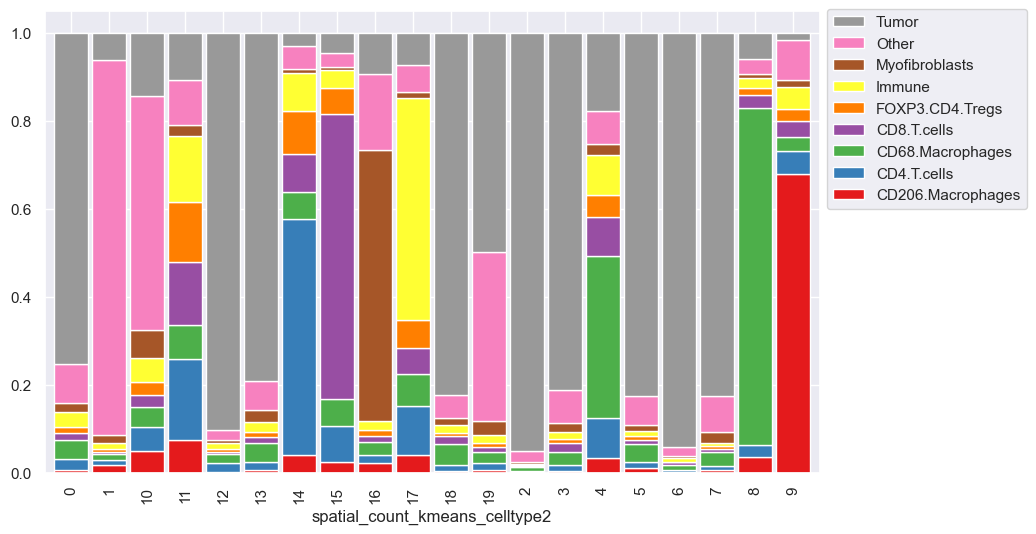

In [14]:
sm.pl.stacked_barplot (Scimap_count_adata, x_axis='spatial_count_kmeans_celltype2', y_axis='celltype', figsize=(10, 6))

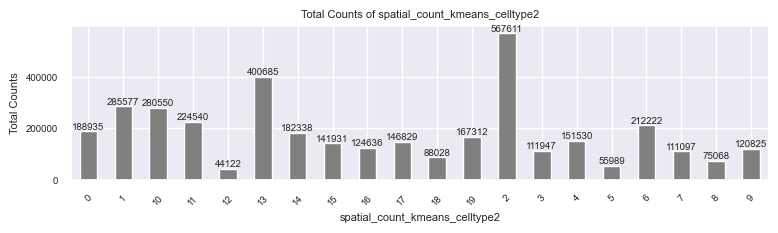

In [79]:
#rpd_order = ['RPD8', 'RPD14', 'RPD10', 'RPD11', 'RPD12', 'RPD1', 'RPD2', 'RPD7', 'RPD9', 'RPD6', 'RPD13', 'RPD3', 'RPD4', 'RPD5']
# Create a dataframe with the RPDs and cell types
df = Scimap_count_adata.obs[['spatial_count_kmeans_celltype2', 'celltype_2']]
# Set the order of RPDs as a categorical type
#df['RPDs'] = pd.Categorical(df['RPDs'], categories=rpd_order, ordered=True)

# Group the data by RPDs and cell types
count_df = df.groupby(['spatial_count_kmeans_celltype2', 'celltype_2']).size().unstack(fill_value=0)

# Get the total counts of each RPD
total_counts = df['spatial_count_kmeans_celltype2'].value_counts().sort_index()

# Plot the stacked bar plot
ax = total_counts.plot(kind='bar', stacked=False, figsize=(9, 2), color='gray', width=0.5)

# Add the total counts to the plot
for i, total in enumerate(total_counts):
    ax.text(i, total + 5, str(total), ha='center', va='bottom', fontsize=7)

# Add labels and title
plt.title('Total Counts of spatial_count_kmeans_celltype2', fontsize=8)
plt.ylabel('Total Counts', fontsize=8)
plt.xlabel('spatial_count_kmeans_celltype2', fontsize=8)
plt.xticks(rotation=45,fontsize=7)
plt.yticks(fontsize=7)
plt.show()

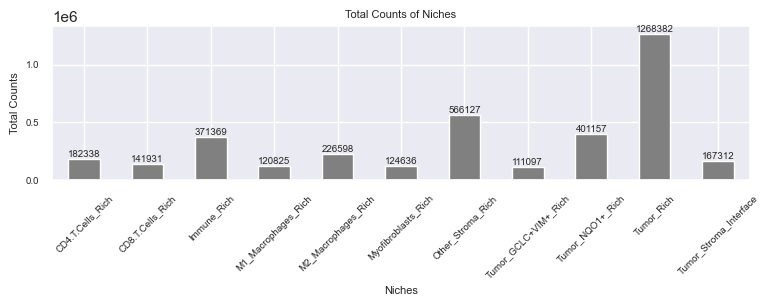

In [185]:
df = Scimap_count_adata.obs[['Niches', 'celltype_2']]
# Set the order of RPDs as a categorical type
#df['RPDs'] = pd.Categorical(df['RPDs'], categories=rpd_order, ordered=True)

# Group the data by RPDs and cell types
count_df = df.groupby(['Niches', 'celltype_2']).size().unstack(fill_value=0)

# Get the total counts of each RPD
total_counts = df['Niches'].value_counts().sort_index()

# Plot the stacked bar plot
ax = total_counts.plot(kind='bar', stacked=False, figsize=(9, 2), color='gray', width=0.5)

# Add the total counts to the plot
for i, total in enumerate(total_counts):
    ax.text(i, total + 5, str(total), ha='center', va='bottom', fontsize=7)

# Add labels and title
plt.title('Total Counts of Niches', fontsize=8)
plt.ylabel('Total Counts', fontsize=8)
plt.xlabel('Niches', fontsize=8)
plt.xticks(rotation=45,fontsize=7)
plt.yticks(fontsize=7)
plt.show()

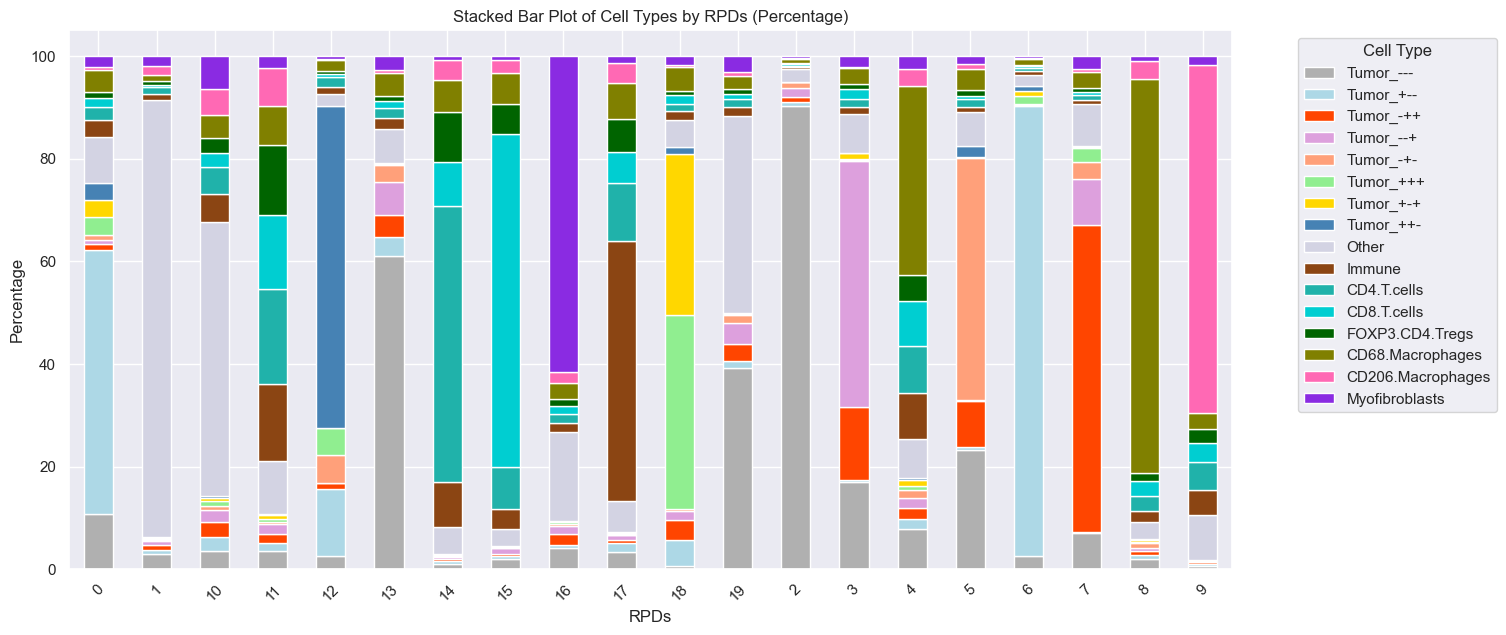

In [80]:
# Plot the distribution of cell types by RPDs
# Create a dataframe with the RPDs and cell types
df = Scimap_count_adata.obs[['spatial_count_kmeans_celltype2', 'celltype_2']]

# Group the data by RPDs and cell types
count_df = df.groupby(['spatial_count_kmeans_celltype2', 'celltype_2']).size().unstack(fill_value=0)

# Get the total counts of each RPD
total_counts = df['spatial_count_kmeans_celltype2'].value_counts().sort_index()
# Calculate the percentage of each cell type in each RPD
percent_df = count_df.div(total_counts, axis=0) * 100



custom_order = ['Tumor_---', 'Tumor_+--', 'Tumor_-++',
                'Tumor_--+', 'Tumor_-+-', 'Tumor_+++',
                'Tumor_+-+', 'Tumor_++-',
                 'Other', 'Immune', 'CD4.T.cells',
                'CD8.T.cells', 'FOXP3.CD4.Tregs', 'CD68.Macrophages',
                'CD206.Macrophages', 'Myofibroblasts']
custom_color = ['#B0B0B0', '#ADD8E6', '#FF4500',
                '#DDA0DD', '#FFA07A', '#90EE90',
                '#FFD700', '#4682B4',
                '#D3D3E3', '#8B4513', '#20B2AA',
                '#00CED1', '#006400', '#808000',
                '#FF69B4', '#8A2BE2']

percent_df = percent_df[custom_order]
# Plot the stacked bar plot
ax = percent_df.plot(kind='bar', stacked=True, figsize=(15, 7), color = custom_color)

# Add the total counts to the plot
#for i, total in enumerate(total_counts):
    #ax.text(i, 100, str(total), ha='center', va='bottom', fontsize=8, rotation=45)

# Add the legend outside the plot
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add labels and title
plt.title('Stacked Bar Plot of Cell Types by RPDs (Percentage)')
plt.xlabel('RPDs')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.show()

## Create RCNs

/var/folders/g1/q5dj_hvs3hg185qg1n_llr7r0000gn/T/ipykernel_7255/377627991.py:3: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



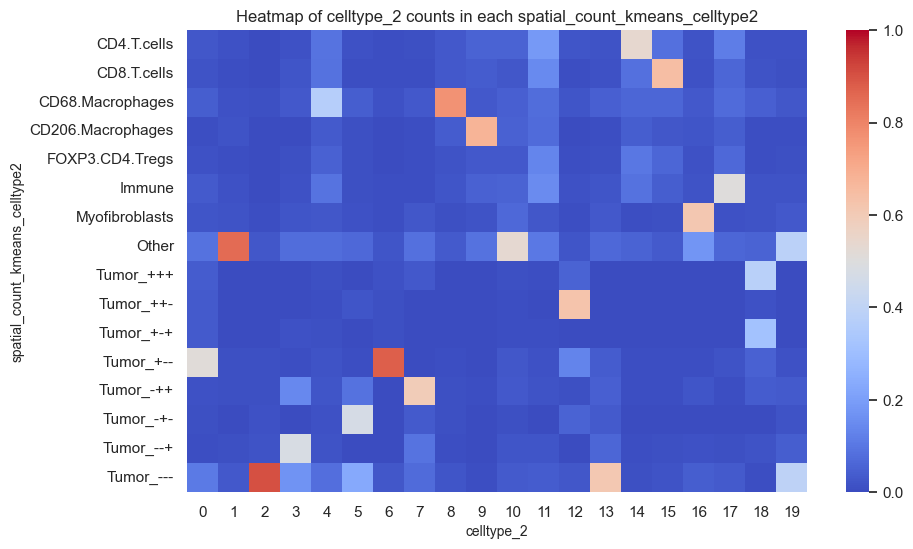

In [69]:
data = Scimap_count_adata.obs[['spatial_count_kmeans_celltype2', 'celltype_2']]

pivot_df = data.pivot_table(index='celltype_2', columns='spatial_count_kmeans_celltype2', aggfunc=len, fill_value=0)

proportion_df = pivot_df.div(pivot_df.sum(axis=0), axis=1)

plt.figure(figsize=(10, 6))
sns.heatmap(proportion_df, cmap='coolwarm',
            annot=False, fmt='d', annot_kws={'size': 8},
            vmin=0, vmax=1,
            #linewidths=0.5, linecolor='black'
            )
plt.title('Heatmap of celltype_2 counts in each spatial_count_kmeans_celltype2', fontsize=12)
plt.xlabel('celltype_2', fontsize=10)
plt.ylabel('spatial_count_kmeans_celltype2', fontsize=10)
plt.show()

In [70]:
Scimap_count_adata.obs

,X_centroid,Y_centroid,core_imageid,cores.x,celltype,Annotation,Stage,patient_id_AB19_1654,Area,Eccentricity,...,interaction_with_FOXP3.CD4.Tregs,interaction_with_CD68.Macrophages,interaction_with_CD206.Macrophages,interaction_with_Immune,interaction_with_Myofibroblasts,interaction_with_Other,RCNs,Niches,interaction_with_CD4.T.cells,interaction_with_CD8.T.cells
19_02_02A_1,2027.642,1011.238,core77_19_02_02A,core77,Other,Invasive border,2,AB19-1654_P10158,282,0.8217004,...,nan,nan,nan,nan,nan,nan,RCN4,Other_Stroma_Rich,nan,nan
19_02_01A_10,5871.136,777.1124,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,258,0.62047,...,False,False,False,False,False,False,RCN1,Tumor_NQO1+_Rich,False,False
19_02_02A_10,1999.424,1195.504,core77_19_02_02A,core77,CD68.Macrophages,Invasive border,2,AB19-1654_P10158,125,0.7554014,...,nan,nan,nan,nan,nan,nan,RCN4,Other_Stroma_Rich,nan,nan
19_02_01A_100,6136.928,858.545,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,222,0.8035844,...,False,False,False,False,False,False,RCN1,Tumor_NQO1+_Rich,False,False
19_02_02A_100,1728.54,1302.083,core77_19_02_02A,core77,Immune,Invasive border,2,AB19-1654_P10158,300,0.5226134,...,nan,nan,nan,nan,nan,nan,RCN4,Other_Stroma_Rich,nan,nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INF1_99998,36889.41,6446.412,core22_INF1,core22,Tumor,Inflammation,unknown,AB19-1654_P10648,148,0.6417798,...,nan,nan,nan,nan,nan,nan,RCN3,Tumor_Rich,nan,nan
1B_99999,11181.53,7239.268,core64_1B,core64,FOXP3.CD4.Tregs,Tumor center,2,AB19-1654_P10561,366,0.7714365,...,nan,nan,nan,nan,nan,nan,RCN5,Immune_Rich,nan,nan
2B_99999,8371.249,6579.823,core71_2B,core71,CD4.T.cells,Lymph node met,2,AB19-1654_P10599,558,0.8634844,...,nan,nan,nan,nan,nan,nan,RCN3,Tumor_Rich,nan,nan
3B_99999,20828.41,4477.018,core42_3B,core42,Tumor,Tumor center,1,AB19-1654_P10620,112,0.8836218,...,nan,nan,nan,nan,nan,nan,RCN3,Tumor_Rich,nan,nan


In [71]:
rename_dict = {'RCN1': ['0', '6'],
               'RCN2': ['7'],
               'RCN3': ['2', '3', '5', '12', '13', '18'],
               'RCN4': ['1', '10'],
               'RCN5': ['11', '17'],
               'RCN6': ['14'],
               'RCN7': ['15'],
               'RCN8': ['16'],
               'RCN9': ['19'],
               'RCN10': ['4', '8'],
               'RCN11': ['9']
                }

replace_dict= {v: k for k, values in rename_dict.items() for v in values}
Scimap_count_adata.obs['spatial_count_kmeans_celltype2'] = Scimap_count_adata.obs['spatial_count_kmeans_celltype2'].astype(str)
Scimap_count_adata.obs['RCNs'] = Scimap_count_adata.obs['spatial_count_kmeans_celltype2'].replace(replace_dict)
Scimap_count_adata

AnnData object with n_obs × n_vars = 3681772 × 25
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'celltype.1', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'celltype_2', 'CellID', 'imageid', 'spatial_count_kmeans_celltype2', 'interaction_with_CD4Tcells', 'interaction_with_CD8Tcells', 'interaction_with_FOXP3.CD4.Tregs', 'interaction_with_CD68.Macrophages', 'interaction_with_CD206.Macrophages', 'interaction_with_Immune', 'interaction_with_Myofibroblasts', 'interaction_with_Other', 'RCNs', 'Niches', 'interaction_with_CD4.T.cells', 'interaction_with_CD8.T.cells'
    uns: 'all_markers', 'spatial_count_celltype2', 'spatial_distance'
    obsm: 'spatial'

In [72]:
rename_dict = {'Tumor_NQO1+_Rich': ['0', '6'],
               'Tumor_GCLC+VIM+_Rich': ['7'],
               'Tumor_Rich': ['2', '3', '5', '12', '13', '18'],
               'Other_Stroma_Rich': ['1', '10'],
               'Immune_Rich': ['11', '17'],
               'CD4.T.Cells_Rich': ['14'],
               'CD8.T.Cells_Rich': ['15'],
               'Myofibroblasts_Rich': ['16'],
               'Tumor_Stroma_Interface': ['19'],
               'M1_Macrophages_Rich': ['4', '8'],
               'M2_Macrophages_Rich': ['9']
                }

replace_dict= {v: k for k, values in rename_dict.items() for v in values}
Scimap_count_adata.obs['spatial_count_kmeans_celltype2'] = Scimap_count_adata.obs['spatial_count_kmeans_celltype2'].astype(str)
Scimap_count_adata.obs['Niches'] = Scimap_count_adata.obs['spatial_count_kmeans_celltype2'].replace(replace_dict)
Scimap_count_adata

AnnData object with n_obs × n_vars = 3681772 × 25
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'celltype.1', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'celltype_2', 'CellID', 'imageid', 'spatial_count_kmeans_celltype2', 'interaction_with_CD4Tcells', 'interaction_with_CD8Tcells', 'interaction_with_FOXP3.CD4.Tregs', 'interaction_with_CD68.Macrophages', 'interaction_with_CD206.Macrophages', 'interaction_with_Immune', 'interaction_with_Myofibroblasts', 'interaction_with_Other', 'RCNs', 'Niches', 'interaction_with_CD4.T.cells', 'interaction_with_CD8.T.cells'
    uns: 'all_markers', 'spatial_count_celltype2', 'spatial_distance'
    obsm: 'spatial'

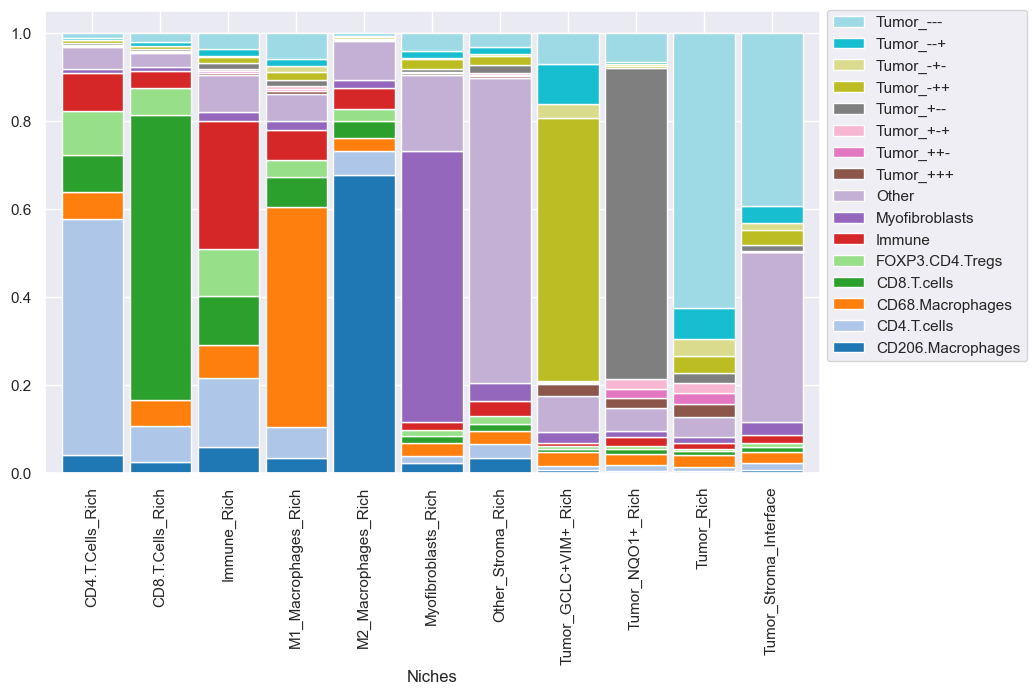

In [73]:
sm.pl.stacked_barplot (Scimap_count_adata, x_axis='Niches', y_axis='celltype_2', figsize=(10, 6))

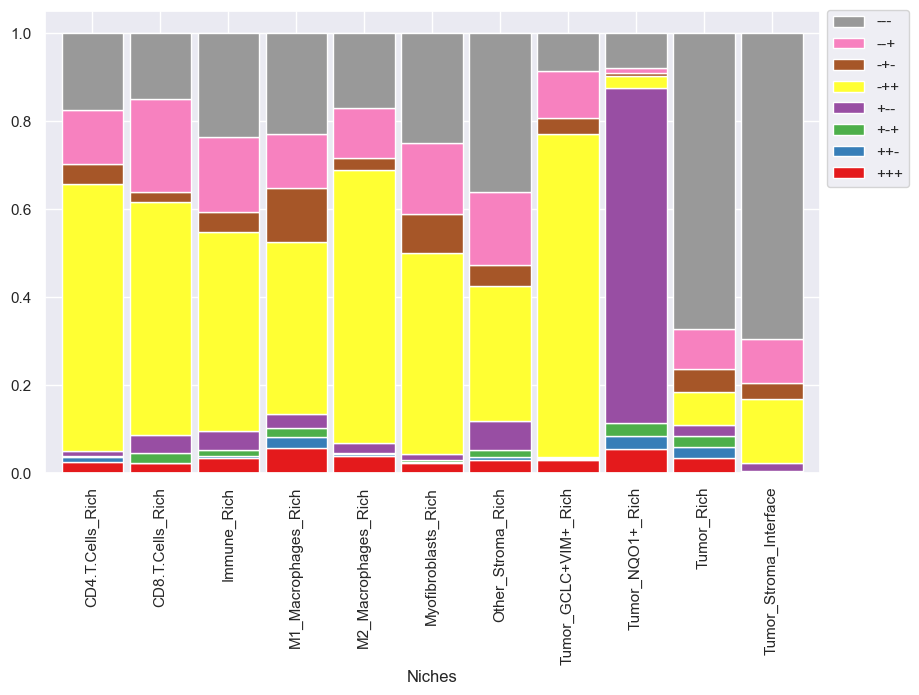

In [74]:
sm.pl.stacked_barplot (Scimap_count_adata, x_axis='Niches', y_axis='NQO1_GCLC_VIM', figsize=(10, 6))

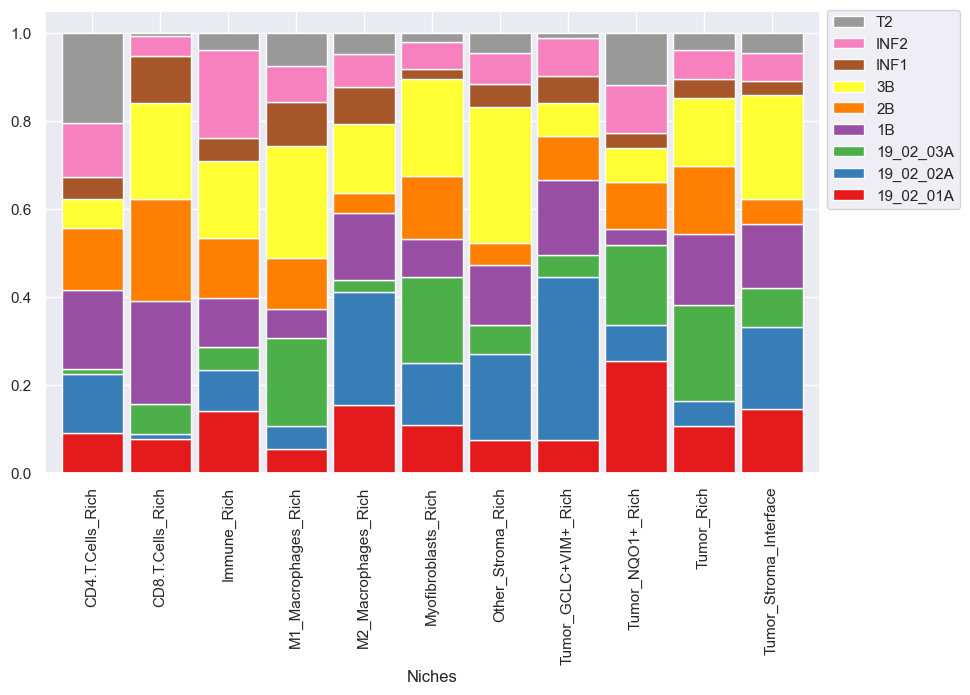

In [75]:
sm.pl.stacked_barplot (Scimap_count_adata, x_axis='Niches', y_axis='imageid', figsize=(10, 6))

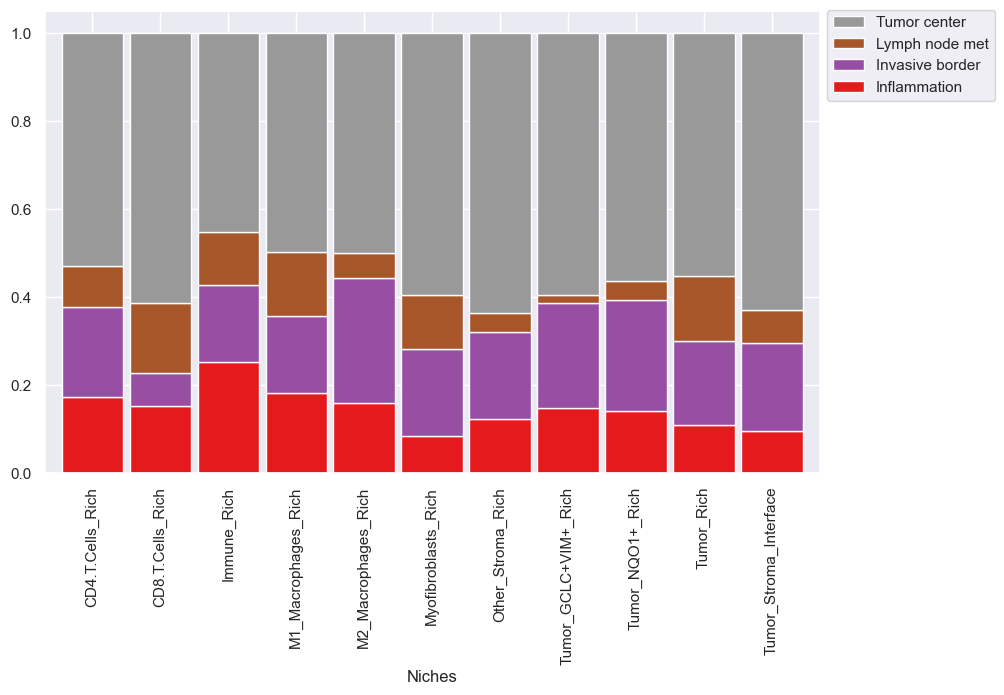

In [76]:
sm.pl.stacked_barplot (Scimap_count_adata, x_axis='Niches', y_axis='Annotation', figsize=(10, 6))

In [77]:
Scimap_count_adata.obs

,X_centroid,Y_centroid,core_imageid,cores.x,celltype,Annotation,Stage,patient_id_AB19_1654,Area,Eccentricity,...,interaction_with_FOXP3.CD4.Tregs,interaction_with_CD68.Macrophages,interaction_with_CD206.Macrophages,interaction_with_Immune,interaction_with_Myofibroblasts,interaction_with_Other,RCNs,Niches,interaction_with_CD4.T.cells,interaction_with_CD8.T.cells
19_02_02A_1,2027.642,1011.238,core77_19_02_02A,core77,Other,Invasive border,2,AB19-1654_P10158,282,0.8217004,...,nan,nan,nan,nan,nan,nan,RCN4,Other_Stroma_Rich,nan,nan
19_02_01A_10,5871.136,777.1124,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,258,0.62047,...,False,False,False,False,False,False,RCN1,Tumor_NQO1+_Rich,False,False
19_02_02A_10,1999.424,1195.504,core77_19_02_02A,core77,CD68.Macrophages,Invasive border,2,AB19-1654_P10158,125,0.7554014,...,nan,nan,nan,nan,nan,nan,RCN4,Other_Stroma_Rich,nan,nan
19_02_01A_100,6136.928,858.545,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,222,0.8035844,...,False,False,False,False,False,False,RCN1,Tumor_NQO1+_Rich,False,False
19_02_02A_100,1728.54,1302.083,core77_19_02_02A,core77,Immune,Invasive border,2,AB19-1654_P10158,300,0.5226134,...,nan,nan,nan,nan,nan,nan,RCN4,Other_Stroma_Rich,nan,nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INF1_99998,36889.41,6446.412,core22_INF1,core22,Tumor,Inflammation,unknown,AB19-1654_P10648,148,0.6417798,...,nan,nan,nan,nan,nan,nan,RCN3,Tumor_Rich,nan,nan
1B_99999,11181.53,7239.268,core64_1B,core64,FOXP3.CD4.Tregs,Tumor center,2,AB19-1654_P10561,366,0.7714365,...,nan,nan,nan,nan,nan,nan,RCN5,Immune_Rich,nan,nan
2B_99999,8371.249,6579.823,core71_2B,core71,CD4.T.cells,Lymph node met,2,AB19-1654_P10599,558,0.8634844,...,nan,nan,nan,nan,nan,nan,RCN3,Tumor_Rich,nan,nan
3B_99999,20828.41,4477.018,core42_3B,core42,Tumor,Tumor center,1,AB19-1654_P10620,112,0.8836218,...,nan,nan,nan,nan,nan,nan,RCN3,Tumor_Rich,nan,nan


In [78]:
Scimap_count_adata_2 = Scimap_count_adata.obs[['X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype',
       'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity',
       'celltype.1', 'antioxidant_NQOI', 'antioxidant_GCLC',
       'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM',
       'celltype_2', 'CellID', 'imageid', 'spatial_count_kmeans_celltype2','RCNs', 'Niches']]

In [79]:
for col in Scimap_count_adata.obs.columns:
    if Scimap_count_adata.obs[col].dtype != 'str':
        Scimap_count_adata.obs[col] = Scimap_count_adata.obs[col].astype(str)
Scimap_count_adata.write('/Volumes/Expansion/Auria/First_milestone_intermediate_files/Scimap_count_adata.h5ad')

# Marker expression within RCNs

In [ ]:
Scimap_count_adata = sc.read_h5ad('/Volumes/Expansion/Auria/First_milestone_intermediate_files/Scimap_count_adata.h5ad')

In [80]:
Scimap_count_adata_tumor = Scimap_count_adata[Scimap_count_adata.obs['celltype'] == 'Tumor']

In [81]:
Scimap_count_adata_tumor.obs

,X_centroid,Y_centroid,core_imageid,cores.x,celltype,Annotation,Stage,patient_id_AB19_1654,Area,Eccentricity,...,interaction_with_FOXP3.CD4.Tregs,interaction_with_CD68.Macrophages,interaction_with_CD206.Macrophages,interaction_with_Immune,interaction_with_Myofibroblasts,interaction_with_Other,RCNs,Niches,interaction_with_CD4.T.cells,interaction_with_CD8.T.cells
19_02_01A_10,5871.136,777.1124,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,258,0.62047,...,False,False,False,False,False,False,RCN1,Tumor_NQO1+_Rich,False,False
19_02_01A_100,6136.928,858.545,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,222,0.8035844,...,False,False,False,False,False,False,RCN1,Tumor_NQO1+_Rich,False,False
T2_100,24071.28,1957.735,core42_T2,core42,Tumor,Tumor center,unknown,AB19-1654_P10680,483,0.6610849,...,False,False,False,False,False,True,RCN4,Other_Stroma_Rich,False,False
19_02_01A_1000,5507.088,1322.723,core77_19_02_01A,core77,Tumor,Tumor center,2,AB19-1654_P10117,444,0.4340857,...,False,False,False,True,False,False,RCN1,Tumor_NQO1+_Rich,False,False
19_02_01A_10000,8528.593,2029.0,core70_19_02_01A,core70,Tumor,Invasive border,2,AB19-1654_P10113,322,0.5691058,...,True,True,False,True,False,False,RCN1,Tumor_NQO1+_Rich,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2B_99998,8296.06,6581.489,core71_2B,core71,Tumor,Lymph node met,2,AB19-1654_P10599,350,0.7529355,...,nan,nan,nan,nan,nan,nan,RCN3,Tumor_Rich,nan,nan
3B_99998,20735.36,4474.095,core42_3B,core42,Tumor,Tumor center,1,AB19-1654_P10620,95,0.8425285,...,nan,nan,nan,nan,nan,nan,RCN3,Tumor_Rich,nan,nan
INF1_99998,36889.41,6446.412,core22_INF1,core22,Tumor,Inflammation,unknown,AB19-1654_P10648,148,0.6417798,...,nan,nan,nan,nan,nan,nan,RCN3,Tumor_Rich,nan,nan
3B_99999,20828.41,4477.018,core42_3B,core42,Tumor,Tumor center,1,AB19-1654_P10620,112,0.8836218,...,nan,nan,nan,nan,nan,nan,RCN3,Tumor_Rich,nan,nan


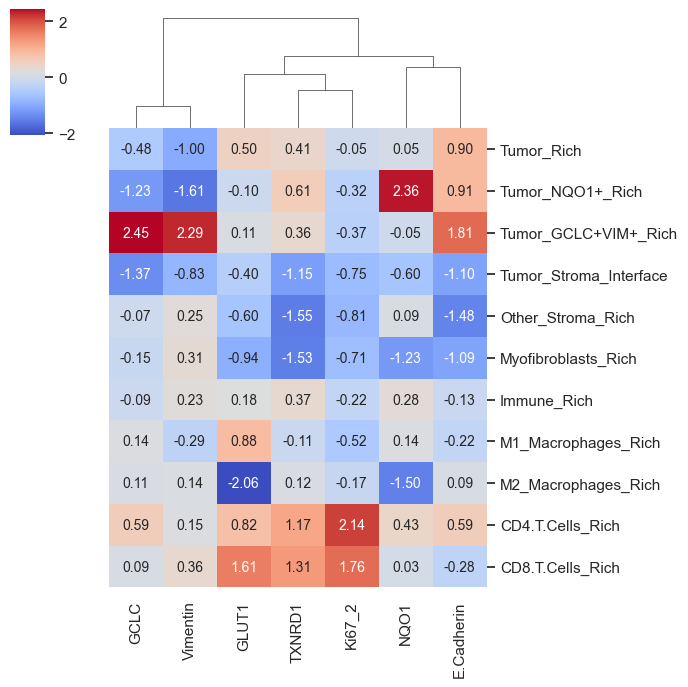

In [83]:
#var_names = Scimap_count_adata_tumor.var.index
#var_names = ['GCLC', 'NQO1', 'TXNRD1', 'GLUT1', 'Ki67_2']
var_names = ['GCLC', 'Vimentin', 'NQO1', 'TXNRD1', 'GLUT1', 'Ki67_2', 'E.Cadherin']
groupby = 'Niches'

niches_order = ['Tumor_Rich', 'Tumor_NQO1+_Rich', 'Tumor_GCLC+VIM+_Rich',
                'Tumor_Stroma_Interface', 'Other_Stroma_Rich', 'Myofibroblasts_Rich',
                'Immune_Rich', 'M1_Macrophages_Rich', 'M2_Macrophages_Rich',
                'CD4.T.Cells_Rich', 'CD8.T.Cells_Rich'
                ]
median_expression = pd.DataFrame(index=niches_order, columns=var_names)

#median_expression = pd.DataFrame(index=Scimap_count_adata_tumor.obs[groupby].unique(), columns=var_names)

for cluster in median_expression.index:
    median_expression.loc[cluster] = np.median(
        Scimap_count_adata_tumor[Scimap_count_adata_tumor.obs[groupby] == cluster, var_names].X, axis=0
    )

median_expression = median_expression.astype(float)
median_expression = median_expression

sns.clustermap(
    median_expression,
    z_score=1,
    figsize=(7, 7),
    cmap="coolwarm",
    annot=True, fmt=".2f",
    annot_kws={'fontsize': 10},
    row_cluster=False,
    col_cluster=True,
    method='ward',
    #linewidths=0.8,
    #linecolor='black'
)

## Bubble chart

In [38]:
Scimap_count_adata = sc.read_h5ad('/Volumes/Expansion/Auria/First_milestone_intermediate_files/Scimap_count_adata.h5ad')

In [43]:
Scimap_count_adata

AnnData object with n_obs × n_vars = 3681772 × 25
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'celltype.1', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'celltype_2', 'CellID', 'imageid', 'spatial_count_kmeans_celltype2', 'interaction_with_CD4Tcells', 'interaction_with_CD8Tcells', 'interaction_with_FOXP3.CD4.Tregs', 'interaction_with_CD68.Macrophages', 'interaction_with_CD206.Macrophages', 'interaction_with_Immune', 'interaction_with_Myofibroblasts', 'interaction_with_Other', 'RCNs', 'Niches', 'interaction_with_CD4.T.cells', 'interaction_with_CD8.T.cells'
    uns: 'all_markers', 'spatial_count_celltype2', 'spatial_distance'
    obsm: 'spatial'

In [270]:
Scimap_count_adata_Immune = Scimap_count_adata[(Scimap_count_adata.obs['celltype'] != 'Tumor') &
                                              (Scimap_count_adata.obs['celltype'] != 'Other')&
                                              (Scimap_count_adata.obs['celltype'] != 'Myofibroblasts')]

In [271]:
Scimap_count_adata_Immune.obs['celltype'].unique()

['CD68.Macrophages', 'Immune', 'FOXP3.CD4.Tregs', 'CD4.T.cells', 'CD206.Macrophages', 'CD8.T.cells']
Categories (6, object): ['CD4.T.cells', 'CD8.T.cells', 'CD68.Macrophages', 'CD206.Macrophages', 'FOXP3.CD4.Tregs', 'Immune']

In [277]:
data = Scimap_count_adata_Immune.obs[['celltype_2','spatial_count_kmeans_celltype2']]
df = pd.DataFrame(data)
df

,celltype_2,spatial_count_kmeans_celltype2
19_02_02A_10,CD68.Macrophages,1
19_02_02A_100,Immune,10
19_02_02A_1000,CD68.Macrophages,10
INF2_1000,FOXP3.CD4.Tregs,11
1B_10000,CD68.Macrophages,11
...,...,...
1B_99995,CD8.T.cells,11
2B_99995,CD4.T.cells,13
19_02_03A_99996,CD206.Macrophages,10
1B_99999,FOXP3.CD4.Tregs,11


In [278]:
df_count = df.groupby(["celltype_2", "spatial_count_kmeans_celltype2"]).size().reset_index(name="Count")
df_pivot = df_count.pivot(index="celltype_2", columns="spatial_count_kmeans_celltype2", values="Count").fillna(0)

/var/folders/g1/q5dj_hvs3hg185qg1n_llr7r0000gn/T/ipykernel_15470/2381458286.py:1: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [281]:
df_pivot

spatial_count_kmeans_celltype2,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,Log2(Fold Change),P_value,-Log10(P value)
celltype_2,,,,,,,,,,,,,,,,,,,,,
CD4.T.cells,4669,3433,1669,1654,13781,781,1197,1116,2133,6424,...,7675,98021,11700,2190,16667,1145,2557,-0.514943,0.820222,0.086068
CD8.T.cells,3270,1483,1291,2198,13512,423,1075,790,2161,4461,...,5250,15470,91918,1835,8899,1633,1641,-0.901195,0.000001,5.968205
CD68.Macrophages,7978,3610,5151,3348,55644,2362,2496,3462,57502,3723,...,17317,11189,8480,3725,10393,4114,4326,-0.551597,0.068716,1.162942
CD206.Macrophages,1267,5023,809,371,5166,564,231,678,2642,81967,...,2638,7317,3563,2758,5796,441,1227,-0.265590,0.002961,2.528597
FOXP3.CD4.Tregs,2319,1949,1021,1137,7679,567,455,755,1245,3388,...,4415,17893,8554,1768,9278,615,1553,-0.413128,0.262570,0.580756
Immune,6545,3720,1882,1710,13677,600,1561,689,1639,5899,...,8732,16000,5590,2322,74213,1546,3081,-0.199541,0.000093,4.031829


In [288]:
df_pivot['-Log10(P value)'].max()

80.68885606898908

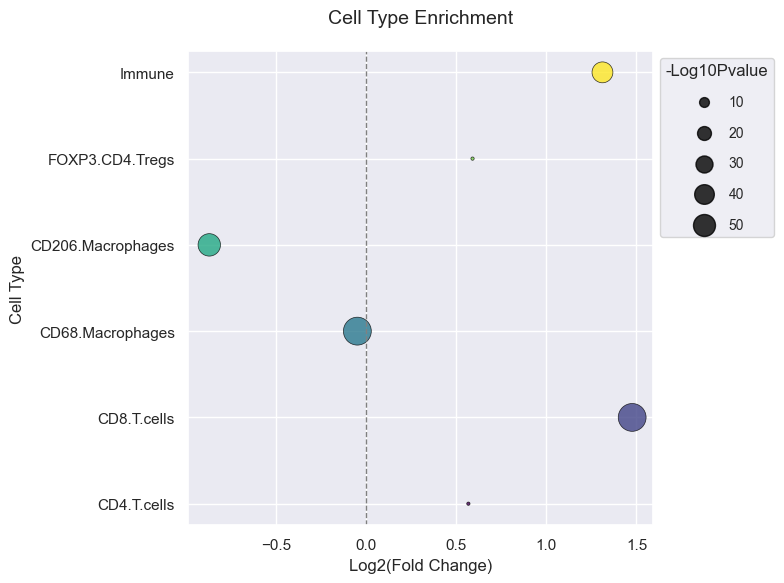

In [291]:
df_pivot["Log2(Fold Change)"] = np.log2(df_pivot["3"] / df_pivot["7"].replace(0, 1))

p_values = []
for cell_type in df_pivot.index:
    count_cluster03 = df_pivot.loc[cell_type, "3"]
    count_cluster07 = df_pivot.loc[cell_type, "7"]
    total_cluster03 = df_pivot["3"].sum()
    total_cluster07 = df_pivot["7"].sum()

    # 构造列联表
    contingency_table = [[count_cluster03, total_cluster03 - count_cluster03], [count_cluster07, total_cluster07 - count_cluster07]]
    _, p_value = fisher_exact(contingency_table)
    p_values.append(p_value)

df_pivot["P_value"] = p_values
df_pivot["-Log10(P value)"] = -np.log10(df_pivot["P_value"].replace(0, 1e-10))  # 避免-log10(0)


colors = plt.cm.viridis(np.linspace(0, 1, len(df_pivot)))

plt.figure(figsize=(8, 6))

# 设置气泡大小（与 -Log10(P value) 成比例）
bubble_size = df_pivot["-Log10(P value)"] * 5

plt.scatter(
    df_pivot["Log2(Fold Change)"],  # x 轴：Log2(Fold Change)
    df_pivot.index,  # y 轴：细胞类型
    s=bubble_size,  # 气泡大小
    c=colors,  # 气泡颜色
    alpha=0.8,  # 透明度
    edgecolors="black",  # 气泡边缘
    linewidth=0.5  # 气泡边缘宽度
)

# 添加参考线
plt.axvline(x=0, color="gray", linestyle="--", linewidth=1.0)

# 添加标题和标签
plt.title("Cell Type Enrichment", fontsize=14, pad=20)
plt.xlabel("Log2(Fold Change)", fontsize=12)
plt.ylabel("Cell Type", fontsize=12)

# 添加图例 - 气泡大小
bubble_sizes_legend = [10, 20, 30, 40, 50]
#bubble_sizes_legend = [50, 100, 150, 200, 250]
for size in bubble_sizes_legend:
    plt.scatter([], [], s=size * 5, color="black", alpha=0.8, edgecolors="black", label=f"{size}")

legend1 = plt.legend(
    title="-Log10Pvalue",  # 图例标题
    title_fontsize=12,  # 标题字体大小
    loc="upper left",  # 图例位置
    bbox_to_anchor=(1, 1),  # 偏移位置
    labelspacing=1.2,  # 标签间距
    frameon=True,  # 图例框架
    fontsize=10  # 标签字体大小
)


# 调整布局
plt.tight_layout()
plt.show()

## spatial distance

In [ ]:
total_gclc_vim_cells = (Scimap_count_adata.obs['celltype_2'] == 'Tumor_+--').sum()
interaction_results = adata.obs['interaction_with_CD206.Macrophages']
gclc_vim_with_immune = interaction_results.sum()
gclc_vim_without_immune = total_gclc_vim_cells - gclc_vim_with_immune

proportion_with_immune = gclc_vim_with_immune / total_gclc_vim_cells
proportion_without_immune = gclc_vim_without_immune / total_gclc_vim_cells

print(f"Total NQO1+ tumor cells: {total_gclc_vim_cells}")
print(f"NQO1+ cells with Other cells within radius: {gclc_vim_with_immune} ({proportion_with_immune:.2%})")
print(f"NQO1+ cells without Other cells within radius: {gclc_vim_without_immune} ({proportion_without_immune:.2%})")

Total NQO1+ tumor cells: 337756
NQO1+ cells with Other cells within radius: 13550 (4.01%)
NQO1+ cells without Other cells within radius: 324206 (95.99%)


In [57]:
Scimap_count_adata = sm.tl.spatial_distance (Scimap_count_adata, phenotype='celltype_2')

Processing Image: 19_02_02A
Processing Image: 19_02_01A
Processing Image: T2
Processing Image: INF2
Processing Image: 19_02_03A
Processing Image: 1B
Processing Image: 2B
Processing Image: 3B
Processing Image: INF1


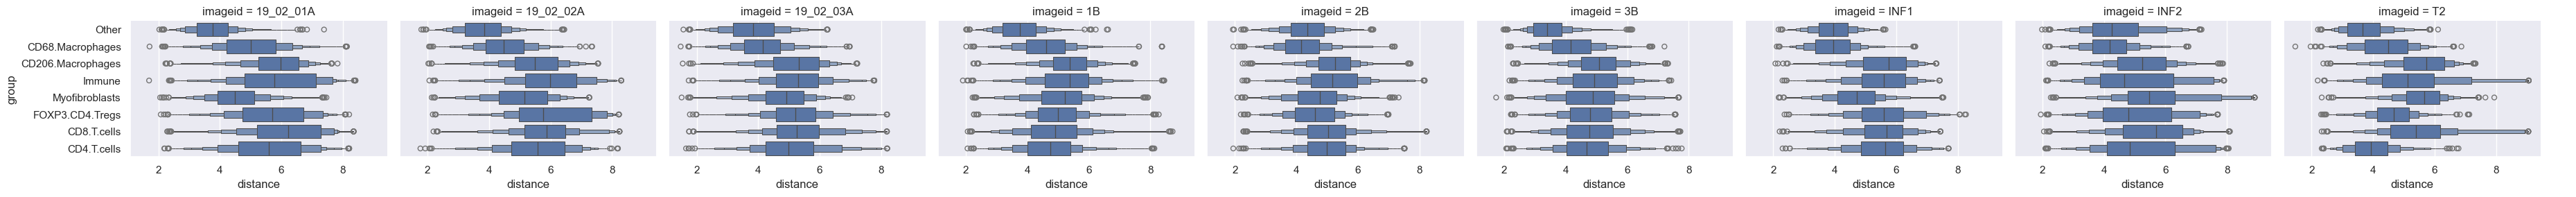

In [58]:
distance_to = ['Other', 'CD68.Macrophages', 'CD206.Macrophages', 'Immune', 'Myofibroblasts', 'FOXP3.CD4.Tregs', 'CD8.T.cells', 'CD4.T.cells']
sm.pl.spatial_distance (Scimap_count_adata, phenotype='celltype_2', method='numeric',
                        distance_from='Tumor_-++', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)

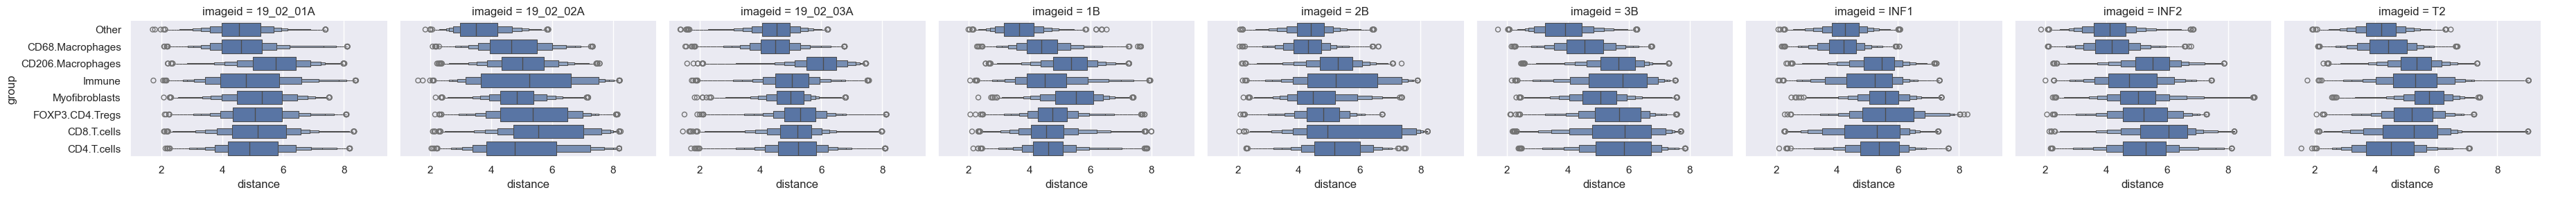

In [59]:
distance_to = ['Other', 'CD68.Macrophages', 'CD206.Macrophages', 'Immune', 'Myofibroblasts', 'FOXP3.CD4.Tregs', 'CD8.T.cells', 'CD4.T.cells']
sm.pl.spatial_distance (Scimap_count_adata, phenotype='celltype_2', method='numeric',
                        distance_from='Tumor_+--', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)

In [96]:
Scimap_count_adata.uns['spatial_distance']

,Other,CD68.Macrophages,Immune,CD4.T.cells,Tumor_-+-,Tumor_---,CD8.T.cells,FOXP3.CD4.Tregs,Tumor_+--,Tumor_-++,Tumor_+-+,CD206.Macrophages,Tumor_+++,Tumor_--+,Myofibroblasts,Tumor_++-
19_02_02A_1,12.671646,181.756343,184.576763,184.167545,574.531987,759.381002,195.944320,224.400010,535.483008,827.965586,2560.880209,248.191569,1628.945653,1042.294055,446.815307,538.024578
19_02_02A_10,13.949055,12.994611,32.964128,67.584777,476.572003,636.399701,98.970935,143.152764,513.378329,757.579640,2381.322252,62.170207,1502.161119,1014.540967,263.031451,473.511332
19_02_02A_100,19.607227,60.509806,14.104766,25.195155,575.043616,689.417190,45.358442,212.714720,784.388131,982.447695,2179.924145,273.145736,1479.290085,1267.352524,314.980655,720.910784
19_02_02A_1000,14.408725,61.643854,26.067688,34.279607,417.466004,406.447976,98.003778,49.203735,458.138835,1155.177031,1684.864301,660.571699,1090.873883,1107.013298,316.155701,630.659329
19_02_02A_1001,14.399349,26.067688,19.266574,42.127077,399.436129,386.713661,110.061467,56.879477,461.617126,1130.234354,1692.179985,642.935853,1091.995352,1108.064036,336.258303,646.475759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INF1_99995,100.833561,77.768982,837.479899,386.438510,213.179930,15.634109,283.725706,555.596156,181.207435,147.981118,1195.255874,546.751911,980.226963,28.324795,418.444716,3237.327620
INF1_99996,48.524948,125.273883,900.392336,254.356453,119.844930,12.277748,121.411545,561.131064,240.908868,26.164411,1295.164911,415.902751,1103.334079,32.015083,328.808074,3065.955485
INF1_99997,59.902249,104.147697,1085.580259,232.614299,95.990304,19.369295,219.459192,718.650905,114.853774,129.566728,1540.919975,183.644430,1389.717590,95.976102,229.289091,2712.046532
INF1_99998,99.446097,89.170354,338.917085,222.519462,391.639176,13.091032,143.523174,182.816450,21.752949,184.030094,1205.395112,226.366454,962.591011,69.032852,276.157533,4531.037569


In [189]:
Scimap_count_adata.obs['celltype_2'].unique()

array(['Other', 'Tumor_+--', 'CD68.Macrophages', 'Immune',
       'FOXP3.CD4.Tregs', 'Tumor_++-', 'CD4.T.cells', 'Tumor_---',
       'Myofibroblasts', 'Tumor_--+', 'CD206.Macrophages', 'Tumor_-+-',
       'Tumor_+-+', 'CD8.T.cells', 'Tumor_-++', 'Tumor_+++'], dtype=object)

In [205]:
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
from joblib import Parallel, delayed

def spatial_interaction_within_radius(adata,
                                      x_coordinate='X_centroid',
                                      y_coordinate='Y_centroid',
                                      z_coordinate=None,
                                      phenotype='celltype_2',
                                      target_phenotype='Tumor_+--',
                                      interacting_phenotype='CD206.Macrophages',
                                      radius=45,
                                      subset=None,
                                      imageid='core_imageid',
                                      verbose=True,
                                      label='spatial_interaction'):
    def interaction_within_radius_internal(adata_subset, x_coordinate, y_coordinate, z_coordinate,
                                           phenotype, target_phenotype, interacting_phenotype, radius, imageid, label):
        if verbose:
            print("Processing Image: " + str(adata_subset.obs[imageid].unique()[0]))
        if z_coordinate is not None:
            if verbose:
                print("Including Z -axis")
            data = pd.DataFrame({'x': adata_subset.obs[x_coordinate], 'y': adata_subset.obs[y_coordinate], 'z': adata_subset.obs[z_coordinate], 'phenotype': adata_subset.obs[phenotype]})
        else:
            data = pd.DataFrame({'x': adata_subset.obs[x_coordinate], 'y': adata_subset.obs[y_coordinate], 'phenotype': adata_subset.obs[phenotype]})

        target_cells = data[data['phenotype'] == target_phenotype]
        interacting_cells = data[data['phenotype'] == interacting_phenotype]

        if len(target_cells) == 0 or len(interacting_cells) == 0:
            return pd.Series([False] * len(target_cells), index=target_cells.index)

        tree = BallTree(interacting_cells[['x', 'y']], metric='euclidean')
        dist, ind = tree.query_radius(target_cells[['x', 'y']], r=radius, return_distance=True)

        interaction = pd.Series([len(d) > 0 for d in dist], index=target_cells.index)
        return interaction

    if subset is not None:
        adata_list = [adata[adata.obs[imageid].isin([subset])]]
    else:
        adata_list = [adata[adata.obs[imageid] == i] for i in adata.obs[imageid].unique()]

    r_interaction_within_radius_internal = lambda x: interaction_within_radius_internal(adata_subset=x,
                                                                                       x_coordinate=x_coordinate, y_coordinate=y_coordinate, z_coordinate=z_coordinate,
                                                                                       phenotype=phenotype, target_phenotype=target_phenotype, interacting_phenotype=interacting_phenotype,
                                                                                       radius=radius, imageid=imageid, label=label)
    all_data = list(map(r_interaction_within_radius_internal, adata_list))

    result = pd.concat(all_data, join='outer')

    adata.obs[label] = result

    return adata

# Calculate the spatial interaction between GCLC+VIM+ tumor cells and CD4T cells within a radius of 45
adata = spatial_interaction_within_radius(Scimap_count_adata, x_coordinate='X_centroid', y_coordinate='Y_centroid',
                                          phenotype='celltype_2', target_phenotype='Tumor_+--', interacting_phenotype='CD206.Macrophages',
                                          radius=45, label='interaction_with_CD206.Macrophages')


Processing Image: core77_19_02_02A
Processing Image: core77_19_02_01A
Processing Image: core42_T2
Processing Image: core42_INF2
Processing Image: core70_19_02_01A
Processing Image: core14_19_02_03A
Processing Image: core63_1B
Processing Image: core77_T2
Processing Image: core64_1B
Processing Image: core71_2B
Processing Image: core42_3B
Processing Image: core22_INF1
Processing Image: core22_19_02_03A
Processing Image: core15_19_02_03A
Processing Image: core7_19_02_03A
Processing Image: core8_19_02_03A
Processing Image: core21_19_02_03A
Processing Image: core1_19_02_03A
Processing Image: core29_T2
Processing Image: core15_INF1
Processing Image: core56_3B
Processing Image: core16_T2
Processing Image: core57_19_02_01A
Processing Image: core1_INF1
Processing Image: core28_3B
Processing Image: core63_19_02_01A
Processing Image: core57_1B
Processing Image: core57_2B
Processing Image: core71_INF1
Processing Image: core58_T2
Processing Image: core50_2B
Processing Image: core50_T2
Processing Ima

/var/folders/g1/q5dj_hvs3hg185qg1n_llr7r0000gn/T/ipykernel_15470/1308757582.py:52: FutureWarning:

The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.



In [206]:
total_gclc_vim_cells = (Scimap_count_adata.obs['celltype_2'] == 'Tumor_+--').sum()
interaction_results = adata.obs['interaction_with_CD206.Macrophages']
gclc_vim_with_immune = interaction_results.sum()
gclc_vim_without_immune = total_gclc_vim_cells - gclc_vim_with_immune

proportion_with_immune = gclc_vim_with_immune / total_gclc_vim_cells
proportion_without_immune = gclc_vim_without_immune / total_gclc_vim_cells

print(f"Total NQO1+ tumor cells: {total_gclc_vim_cells}")
print(f"NQO1+ cells with Other cells within radius: {gclc_vim_with_immune} ({proportion_with_immune:.2%})")
print(f"NQO1+ cells without Other cells within radius: {gclc_vim_without_immune} ({proportion_without_immune:.2%})")

Total NQO1+ tumor cells: 337756
NQO1+ cells with Other cells within radius: 13550 (4.01%)
NQO1+ cells without Other cells within radius: 324206 (95.99%)


In [130]:
Scimap_count_adata.obs['interaction_with_Other'].value_counts()

interaction_with_Other
False    74926
True     72140
Name: count, dtype: int64

In [187]:
Scimap_count_adata.obs['celltype'].value_counts()

celltype
Tumor                1773160
Other                 637369
CD68.Macrophages      235804
CD4.T.cells           234266
Immune                199048
CD8.T.cells           197684
CD206.Macrophages     153362
Myofibroblasts        147812
FOXP3.CD4.Tregs       103267
Name: count, dtype: int64

## INF2

In [44]:
INF2 = Scimap_count_adata[(Scimap_count_adata.obs['imageid'] == 'INF2')]

In [45]:
INF2.obs

,X_centroid,Y_centroid,core_imageid,cores.x,celltype,Annotation,Stage,patient_id_AB19_1654,Area,Eccentricity,...,interaction_with_FOXP3.CD4.Tregs,interaction_with_CD68.Macrophages,interaction_with_CD206.Macrophages,interaction_with_Immune,interaction_with_Myofibroblasts,interaction_with_Other,RCNs,Niches,interaction_with_CD4.T.cells,interaction_with_CD8.T.cells
INF2_1000,24342.76,1470.506,core42_INF2,core42,FOXP3.CD4.Tregs,Inflammation,2,AB19-1654_P10561,79,0.6762032,...,nan,nan,nan,nan,nan,nan,RCN5,Immune_Rich,nan,nan
INF2_1001,24386.07,1469.75,core42_INF2,core42,CD4.T.cells,Inflammation,2,AB19-1654_P10561,60,0.6114881,...,nan,nan,nan,nan,nan,nan,RCN5,Immune_Rich,nan,nan
INF2_1002,24330.01,1472.162,core42_INF2,core42,FOXP3.CD4.Tregs,Inflammation,2,AB19-1654_P10561,173,0.7339441,...,nan,nan,nan,nan,nan,nan,RCN5,Immune_Rich,nan,nan
INF2_1003,24424.06,1473.431,core42_INF2,core42,FOXP3.CD4.Tregs,Inflammation,2,AB19-1654_P10561,123,0.7519862,...,nan,nan,nan,nan,nan,nan,RCN5,Immune_Rich,nan,nan
INF2_1004,24454.99,1470.632,core42_INF2,core42,Immune,Inflammation,2,AB19-1654_P10561,95,0.7680838,...,nan,nan,nan,nan,nan,nan,RCN5,Immune_Rich,nan,nan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INF2_99699,41337.66,4310.933,core14_INF2,core14,Tumor,Inflammation,unknown,AB19-1654_P10711,415,0.7898941,...,nan,nan,nan,nan,nan,nan,RCN3,Tumor_Rich,nan,nan
INF2_997,24560.77,1469.787,core42_INF2,core42,FOXP3.CD4.Tregs,Inflammation,2,AB19-1654_P10561,94,0.7048077,...,nan,nan,nan,nan,nan,nan,RCN5,Immune_Rich,nan,nan
INF2_99700,41317.93,4315.393,core14_INF2,core14,Tumor,Inflammation,unknown,AB19-1654_P10711,122,0.3805421,...,nan,nan,nan,nan,nan,nan,RCN3,Tumor_Rich,nan,nan
INF2_998,24445.84,1467.636,core42_INF2,core42,CD4.T.cells,Inflammation,2,AB19-1654_P10561,99,0.8062132,...,nan,nan,nan,nan,nan,nan,RCN5,Immune_Rich,nan,nan


/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



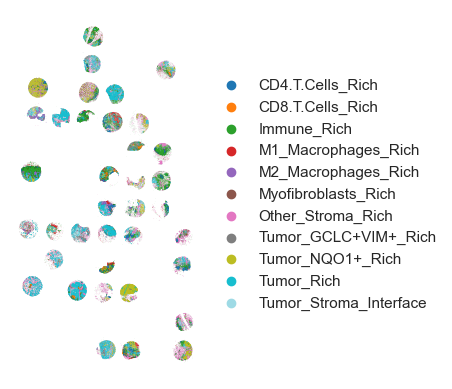

In [46]:
sc.pl.spatial(INF2, color='Niches', spot_size=30, title='', frameon=False, show=True, palette='tab20')

### Core_79

In [158]:
INF2_Core_79 = INF2[INF2.obs['core_imageid'] == 'core79_INF2']

In [159]:
INF2_Core_79.obs

,X_centroid,Y_centroid,core_imageid,cores.x,celltype,Annotation,Stage,patient_id_AB19_1654,Area,Eccentricity,...,interaction_with_CD4Tcells,interaction_with_CD8Tcells,interaction_with_FOXP3.CD4.Tregs,interaction_with_CD68.Macrophages,interaction_with_CD206.Macrophages,interaction_with_Immune,interaction_with_Myofibroblasts,interaction_with_Other,RCNs,Niches
INF2_177068,5471.491,10200.41,core79_INF2,core79,Tumor,Inflammation,2,AB19-1654_P10601,340,0.813855,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RCN1,Tumor_NQO1+_Rich
INF2_177069,5535.209,10202.91,core79_INF2,core79,Other,Inflammation,2,AB19-1654_P10601,211,0.631736,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RCN1,Tumor_NQO1+_Rich
INF2_177070,5479.929,10210.07,core79_INF2,core79,Tumor,Inflammation,2,AB19-1654_P10601,169,0.255912,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RCN1,Tumor_NQO1+_Rich
INF2_177071,5493.954,10207.06,core79_INF2,core79,Tumor,Inflammation,2,AB19-1654_P10601,217,0.549014,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RCN1,Tumor_NQO1+_Rich
INF2_177072,5544.870,10215.72,core79_INF2,core79,Tumor,Inflammation,2,AB19-1654_P10601,269,0.784027,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RCN3,Tumor_Rich
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INF2_282337,6235.488,12864.72,core79_INF2,core79,Immune,Inflammation,2,AB19-1654_P10601,203,0.603620,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RCN5,Immune_Rich
INF2_282338,6152.227,12872.15,core79_INF2,core79,Other,Inflammation,2,AB19-1654_P10601,379,0.664155,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RCN5,Immune_Rich
INF2_282339,6221.947,12872.33,core79_INF2,core79,Other,Inflammation,2,AB19-1654_P10601,266,0.625626,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RCN5,Immune_Rich
INF2_282340,6175.866,12886.73,core79_INF2,core79,Immune,Inflammation,2,AB19-1654_P10601,313,0.729799,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RCN5,Immune_Rich


/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



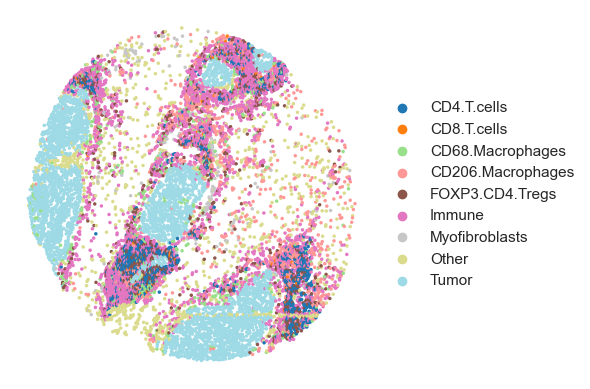

In [160]:
sc.pl.spatial(INF2_Core_79, color='celltype', spot_size=30, title='', frameon=False, show=True, palette='tab20')

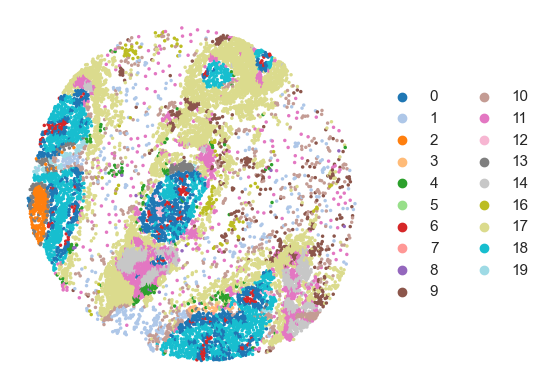

In [161]:
sc.pl.spatial(INF2_Core_79, color='spatial_count_kmeans_celltype2', spot_size=30, title='', frameon=False, show=True, palette='tab20')

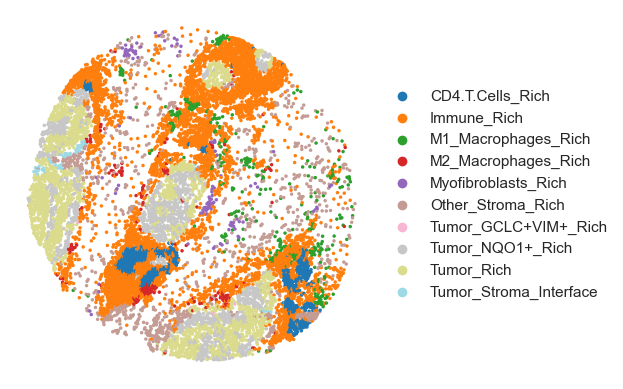

In [162]:
sc.pl.spatial(INF2_Core_79, color='Niches', spot_size=30, title='', frameon=False, show=True, palette='tab20')

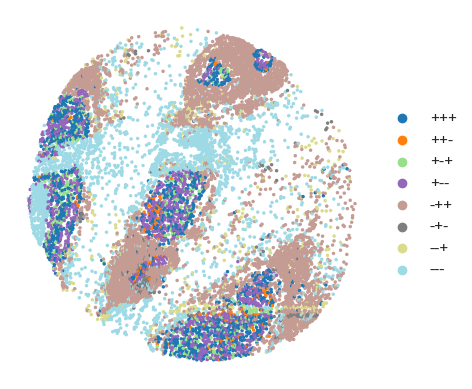

In [22]:
sc.pl.spatial(INF2_Core_79, color='NQO1_GCLC_VIM', spot_size=30, title='', frameon=False, show=True, palette='tab20')

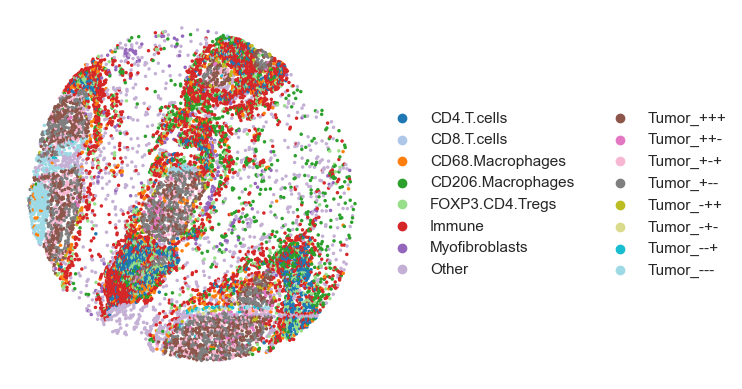

In [23]:
sc.pl.spatial(INF2_Core_79, color='celltype_2', spot_size=30, title='', frameon=False, show=True, palette='tab20')

In [170]:
INF2_Core_79 = sm.tl.spatial_distance (INF2_Core_79, phenotype='Niches')

Processing Image: INF2


In [25]:
INF2_Core_79 = sm.tl.spatial_distance (INF2_Core_79, phenotype='celltype')

Processing Image: INF2


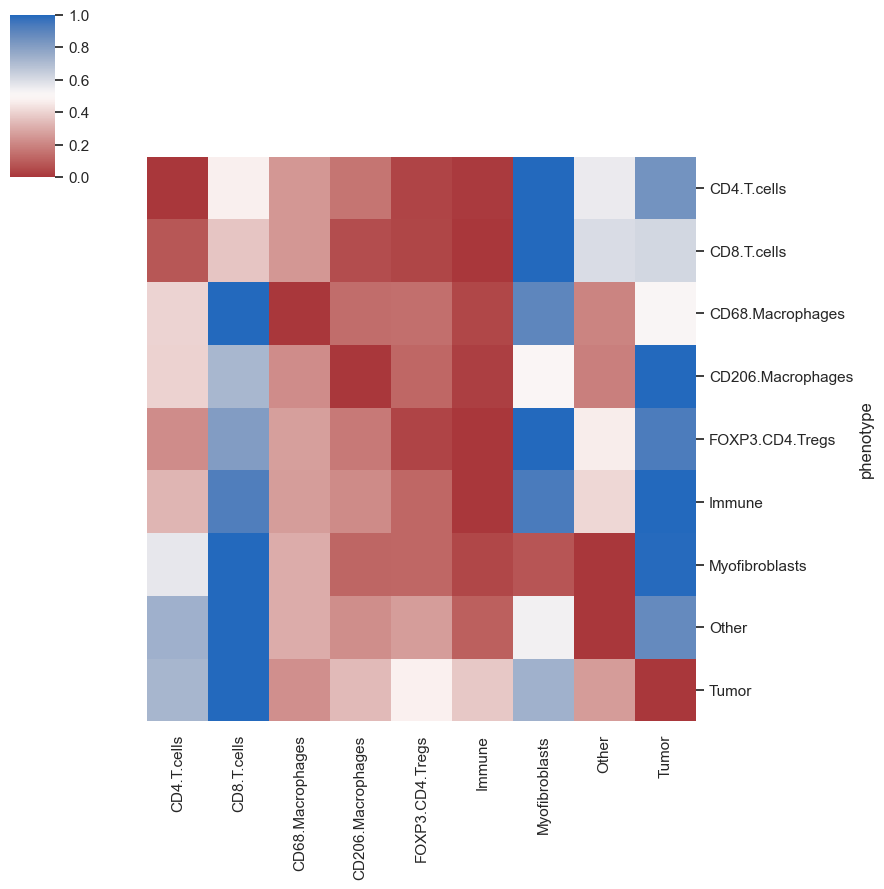

In [26]:
sm.pl.spatial_distance (INF2_Core_79, phenotype='celltype', figsize=(9,9))

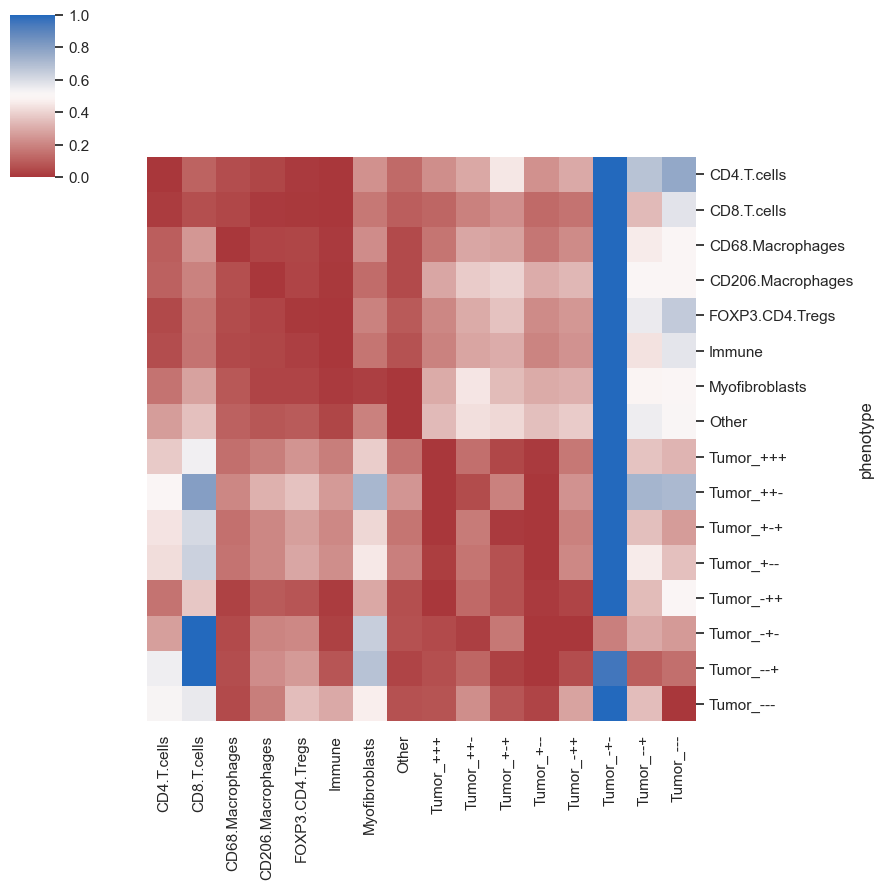

In [29]:
sm.pl.spatial_distance (INF2_Core_79, phenotype='celltype_2', figsize=(9,9))

In [171]:
INF2_Core_79.obs['Niches'].unique()

['Tumor_NQO1+_Rich', 'Tumor_Rich', 'Other_Stroma_Rich', 'Immune_Rich', 'Myofibroblasts_Rich', 'M1_Macrophages_Rich', 'Tumor_Stroma_Interface', 'M2_Macrophages_Rich', 'Tumor_GCLC+VIM+_Rich', 'CD4.T.Cells_Rich']
Categories (10, object): ['CD4.T.Cells_Rich', 'Immune_Rich', 'M1_Macrophages_Rich', 'M2_Macrophages_Rich', ..., 'Tumor_GCLC+VIM+_Rich', 'Tumor_NQO1+_Rich', 'Tumor_Rich', 'Tumor_Stroma_Interface']

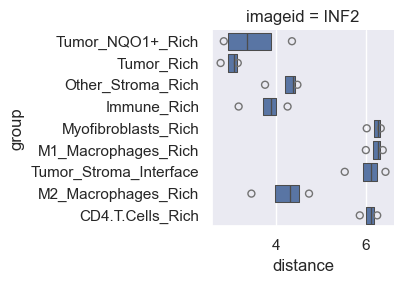

In [ ]:
distance_to = ['Tumor_NQO1+_Rich', 'Tumor_Rich', 'Other_Stroma_Rich',
               'Immune_Rich', 'Myofibroblasts_Rich', 'M1_Macrophages_Rich', 'Tumor_Stroma_Interface', 
               'M2_Macrophages_Rich', 'CD4.T.Cells_Rich']
sm.pl.spatial_distance (INF2_Core_79, phenotype='Niches', method='numeric',
                        distance_from='Tumor_GCLC+VIM+_Rich', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)


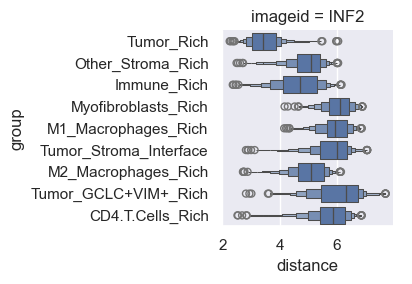

In [175]:
distance_to = [ 'Tumor_Rich', 'Other_Stroma_Rich',
               'Immune_Rich', 'Myofibroblasts_Rich', 'M1_Macrophages_Rich', 'Tumor_Stroma_Interface', 
               'M2_Macrophages_Rich', 'Tumor_GCLC+VIM+_Rich', 'CD4.T.Cells_Rich']
sm.pl.spatial_distance (INF2_Core_79, phenotype='Niches', method='numeric',
                        distance_from='Tumor_NQO1+_Rich', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)

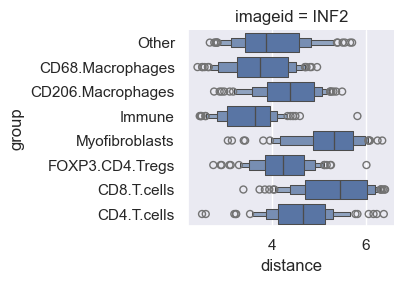

In [31]:
distance_to = ['Other', 'CD68.Macrophages', 'CD206.Macrophages', 'Immune', 'Myofibroblasts', 'FOXP3.CD4.Tregs', 'CD8.T.cells', 'CD4.T.cells']
sm.pl.spatial_distance (INF2_Core_79, phenotype='celltype_2', method='numeric',
                        distance_from='Tumor_-++', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)

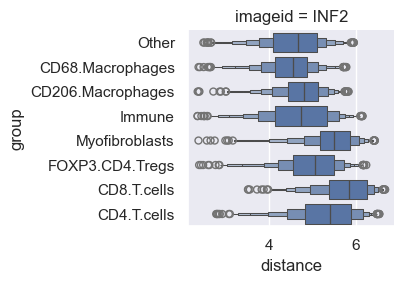

In [33]:
distance_to = ['Other', 'CD68.Macrophages', 'CD206.Macrophages', 'Immune', 'Myofibroblasts', 'FOXP3.CD4.Tregs', 'CD8.T.cells', 'CD4.T.cells']
sm.pl.spatial_distance (INF2_Core_79, phenotype='celltype_2', method='numeric',
                        distance_from='Tumor_+--', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)

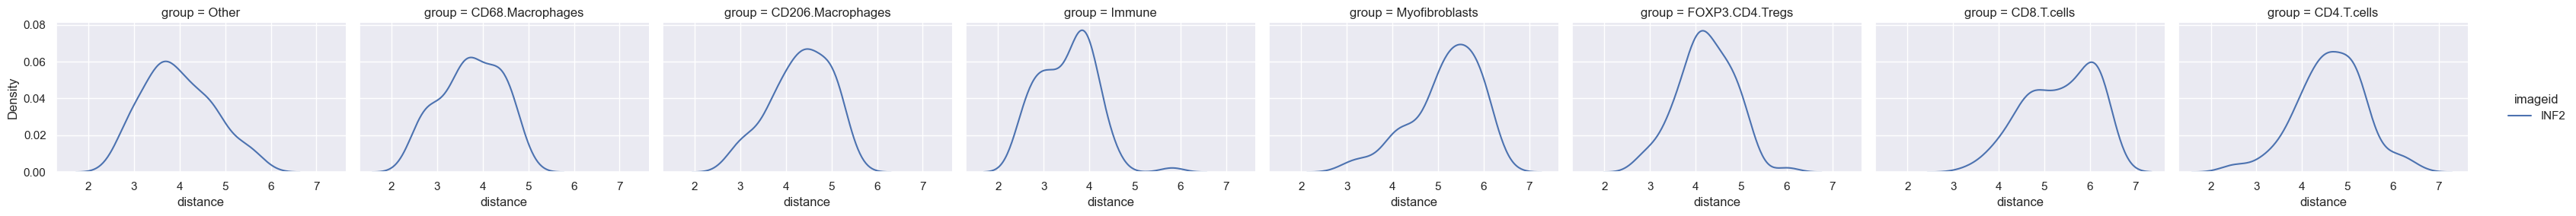

In [32]:
distance_to = ['Other', 'CD68.Macrophages', 'CD206.Macrophages', 'Immune', 'Myofibroblasts', 'FOXP3.CD4.Tregs', 'CD8.T.cells', 'CD4.T.cells']
sm.pl.spatial_distance (INF2_Core_79, phenotype='celltype_2', method='distribution',
                        distance_from='Tumor_-++', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)

In [93]:
INF2_Core_79

AnnData object with n_obs × n_vars = 10829 × 25
    obs: 'X_centroid', 'Y_centroid', 'core_imageid', 'cores.x', 'celltype', 'Annotation', 'Stage', 'patient_id_AB19_1654', 'Area', 'Eccentricity', 'celltype.1', 'antioxidant_NQOI', 'antioxidant_GCLC', 'antioxidant_TXNRD1', 'antioxidant_GLUT1', 'NQO1_GCLC_VIM', 'celltype_2', 'CellID', 'imageid', 'spatial_count_kmeans_celltype2'
    uns: 'all_markers', 'spatial_count_celltype2', 'spatial_count_kmeans_celltype2_colors', 'celltype_colors', 'NQO1_GCLC_VIM_colors', 'celltype_2_colors', 'spatial_distance'
    obsm: 'spatial'

In [95]:
INF2_Core_79.uns['spatial_distance']

,Tumor_---,Other,Tumor_+--,CD68.Macrophages,CD206.Macrophages,Immune,Myofibroblasts,FOXP3.CD4.Tregs,CD8.T.cells,Tumor_+++,Tumor_++-,Tumor_-++,Tumor_+-+,Tumor_--+,CD4.T.cells,Tumor_-+-
INF2_177068,31.600989,63.767025,12.826357,40.743027,112.910007,474.539931,617.702605,495.225557,633.832464,166.729415,208.007784,407.950619,186.016013,412.976705,655.860316,1015.853660
INF2_177069,16.044657,187.877601,11.156451,30.523986,172.455390,449.919400,591.469480,477.756564,671.165074,198.864278,264.799361,438.349731,220.875689,467.123090,597.888934,998.017892
INF2_177070,12.826357,55.741762,12.796958,28.065716,117.351340,462.617620,610.332431,483.527183,631.052375,171.851917,211.172444,413.936287,181.735031,415.228395,644.089726,1004.282928
INF2_177071,23.426670,41.463207,14.344362,21.920404,131.630296,460.994732,616.843052,482.612202,641.951289,186.171445,225.169781,428.280280,191.869561,428.890518,632.745122,1003.558610
INF2_177072,17.670071,16.044657,13.435185,31.778034,179.209151,434.716796,577.577225,463.520131,667.833074,185.110950,269.543687,423.689469,207.756248,470.042153,583.371210,983.473204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INF2_282337,543.145530,15.532894,581.766339,74.053463,24.660743,11.515164,286.406773,99.373190,348.659222,561.710442,567.968961,547.620646,597.300100,701.588372,191.810611,935.655703
INF2_282338,540.413011,17.376077,593.155048,57.479857,32.046197,18.411905,304.335251,86.564786,358.918880,568.151896,594.739231,576.910935,635.416105,734.646022,224.201309,963.065886
INF2_282339,548.130908,69.720232,591.454280,85.189705,27.275238,15.328341,294.147515,109.873600,355.382693,571.984692,577.862584,557.874390,608.905105,712.548498,201.418836,945.914175
INF2_282340,556.502457,27.773706,608.983154,65.795557,40.160189,13.830763,313.380839,114.183115,370.666573,583.008408,602.166384,583.464394,639.026275,740.182873,228.094277,970.744094


## 2B

In [163]:
Scimap_count_adata_2B = Scimap_count_adata[(Scimap_count_adata.obs['imageid'] == '2B')]

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializi

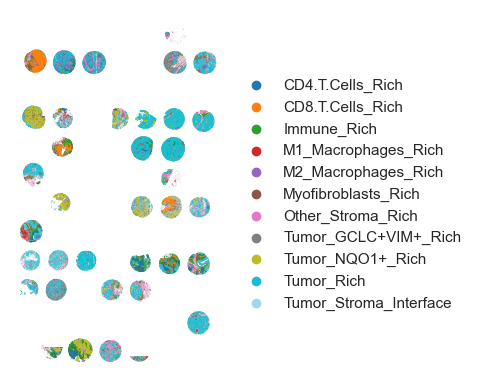

In [164]:
sc.pl.spatial(Scimap_count_adata_2B, color='Niches', spot_size=30, title='', frameon=False, show=True, palette='tab20')

### Core_15

In [165]:
Scimap_count_adata_2B_Core_15 = Scimap_count_adata_2B[Scimap_count_adata_2B.obs['core_imageid'] == 'core15_2B']

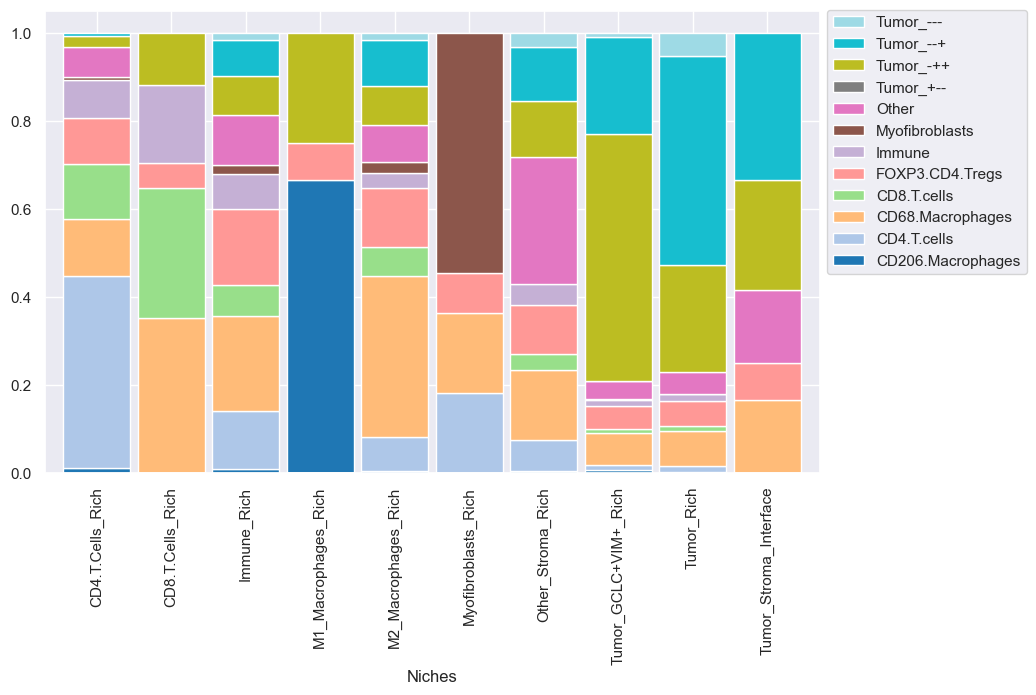

In [166]:
sm.pl.stacked_barplot (Scimap_count_adata_2B_Core_15, x_axis='Niches', y_axis='celltype_2', figsize=(10, 6))

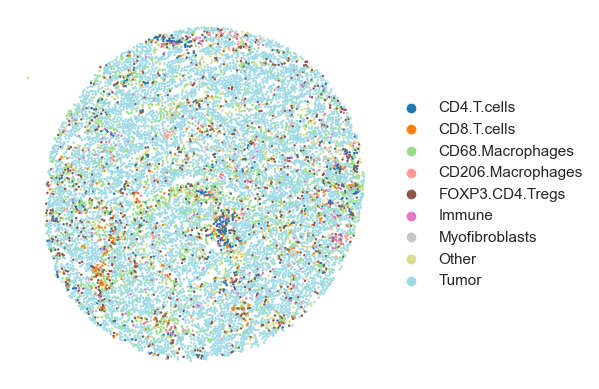

In [43]:
sc.pl.spatial(Scimap_count_adata_2B_Core_15, color='celltype', spot_size=20, title='', frameon=False, show=True, palette='tab20')

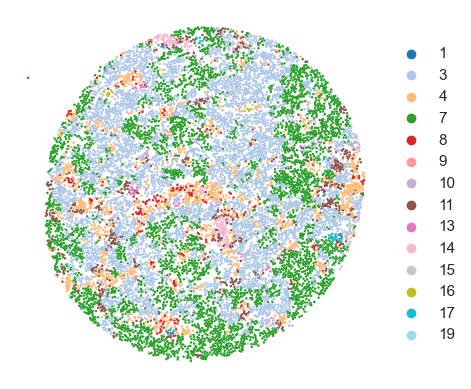

In [42]:
sc.pl.spatial(Scimap_count_adata_2B_Core_15, color='spatial_count_kmeans_celltype2', spot_size=20, title='', frameon=False, show=True, palette='tab20')

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



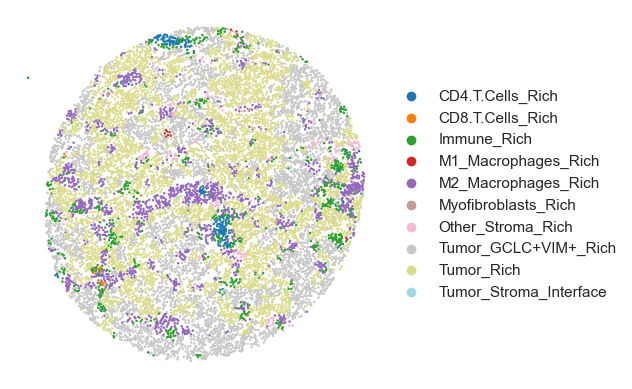

In [167]:
sc.pl.spatial(Scimap_count_adata_2B_Core_15, color='Niches', spot_size=20, title='', frameon=False, show=True, palette='tab20')

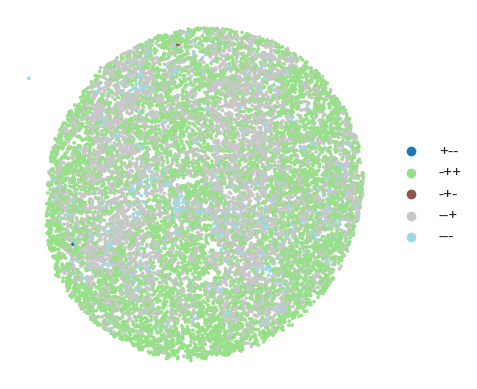

In [39]:
sc.pl.spatial(Scimap_count_adata_2B_Core_15, color='NQO1_GCLC_VIM', spot_size=30, title='', frameon=False, show=True, palette='tab20')

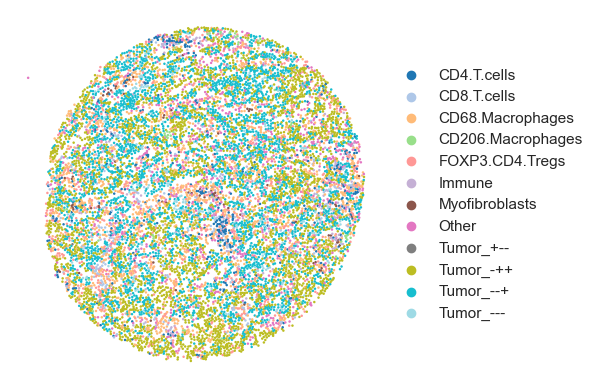

In [41]:
sc.pl.spatial(Scimap_count_adata_2B_Core_15, color='celltype_2', spot_size=20, title='', frameon=False, show=True, palette='tab20')

In [51]:
Scimap_count_adata_2B_Core_15 = sm.tl.spatial_distance (Scimap_count_adata_2B_Core_15, phenotype='celltype_2')

Processing Image: 2B


In [176]:
Scimap_count_adata_2B_Core_15 = sm.tl.spatial_distance (Scimap_count_adata_2B_Core_15, phenotype='Niches')

Processing Image: 2B


In [178]:
Scimap_count_adata_2B_Core_15.obs['Niches'].unique()

['Tumor_Rich', 'M2_Macrophages_Rich', 'Tumor_GCLC+VIM+_Rich', 'CD4.T.Cells_Rich', 'Immune_Rich', 'Other_Stroma_Rich', 'Tumor_Stroma_Interface', 'M1_Macrophages_Rich', 'Myofibroblasts_Rich', 'CD8.T.Cells_Rich']
Categories (10, object): ['CD4.T.Cells_Rich', 'CD8.T.Cells_Rich', 'Immune_Rich', 'M1_Macrophages_Rich', ..., 'Other_Stroma_Rich', 'Tumor_GCLC+VIM+_Rich', 'Tumor_Rich', 'Tumor_Stroma_Interface']

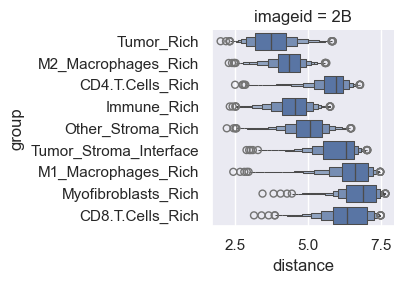

In [179]:
distance_to = ['Tumor_Rich', 'M2_Macrophages_Rich',
               'CD4.T.Cells_Rich', 'Immune_Rich', 'Other_Stroma_Rich', 'Tumor_Stroma_Interface', 
               'M1_Macrophages_Rich', 'Myofibroblasts_Rich', 'CD8.T.Cells_Rich']

sm.pl.spatial_distance (Scimap_count_adata_2B_Core_15, phenotype='Niches', method='numeric',
                        distance_from='Tumor_GCLC+VIM+_Rich', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)

In [ ]:
distance_to = ['Tumor_Rich', 'M2_Macrophages_Rich', 'Tumor_GCLC+VIM+_Rich', 
               'CD4.T.Cells_Rich', 'Immune_Rich', 'Other_Stroma_Rich', 'Tumor_Stroma_Interface', 
               'M1_Macrophages_Rich', 'Myofibroblasts_Rich', 'CD8.T.Cells_Rich']
sm.pl.spatial_distance (Scimap_count_adata_2B_Core_15, phenotype='Niches', method='numeric',
                        distance_from='Tumor_NQO1+_Rich', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)

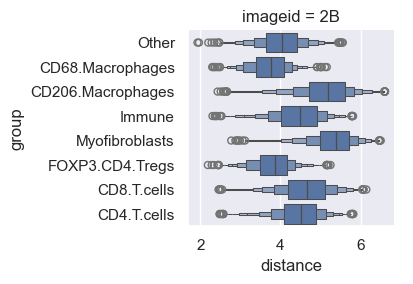

In [52]:
distance_to = ['Other', 'CD68.Macrophages', 'CD206.Macrophages', 'Immune', 'Myofibroblasts', 'FOXP3.CD4.Tregs', 'CD8.T.cells', 'CD4.T.cells']
sm.pl.spatial_distance (Scimap_count_adata_2B_Core_15, phenotype='celltype_2', method='numeric',
                        distance_from='Tumor_-++', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)

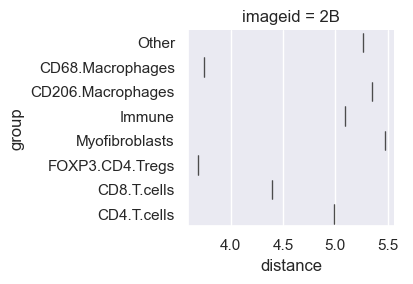

In [53]:
distance_to = ['Other', 'CD68.Macrophages', 'CD206.Macrophages', 'Immune', 'Myofibroblasts', 'FOXP3.CD4.Tregs', 'CD8.T.cells', 'CD4.T.cells']
sm.pl.spatial_distance (Scimap_count_adata_2B_Core_15, phenotype='celltype_2', method='numeric',
                        distance_from='Tumor_+--', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)

### Core_39

In [168]:
Scimap_count_adata_2B_Core_39 = Scimap_count_adata_2B[Scimap_count_adata_2B.obs['core_imageid'] == 'core39_2B']

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



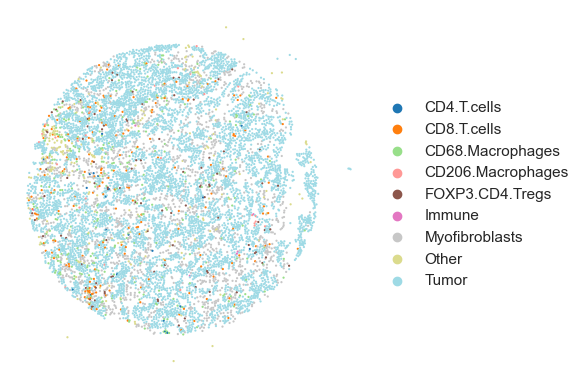

In [46]:
sc.pl.spatial(Scimap_count_adata_2B_Core_39, color='celltype', spot_size=20, title='', frameon=False, show=True, palette='tab20')

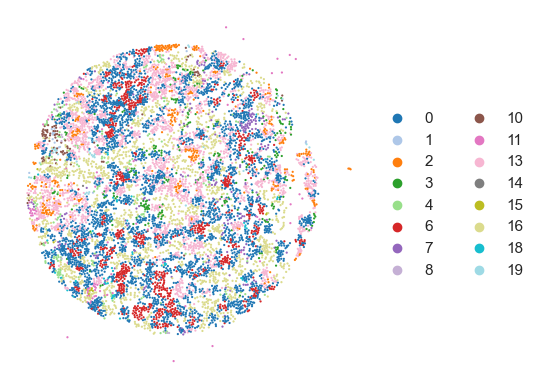

In [47]:
sc.pl.spatial(Scimap_count_adata_2B_Core_39, color='spatial_count_kmeans_celltype2', spot_size=20, title='', frameon=False, show=True, palette='tab20')

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



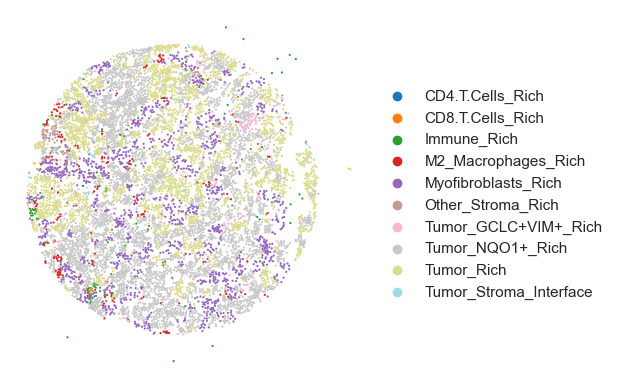

In [169]:
sc.pl.spatial(Scimap_count_adata_2B_Core_39, color='Niches', spot_size=20, title='', frameon=False, show=True, palette='tab20')

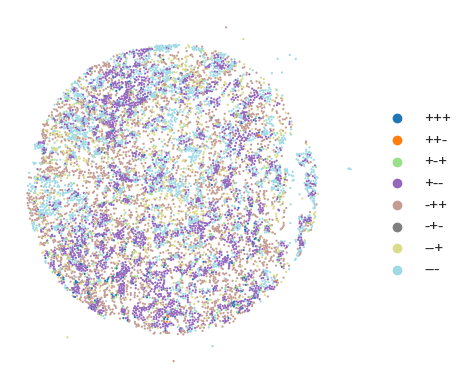

In [48]:
sc.pl.spatial(Scimap_count_adata_2B_Core_39, color='NQO1_GCLC_VIM', spot_size=20, title='', frameon=False, show=True, palette='tab20')

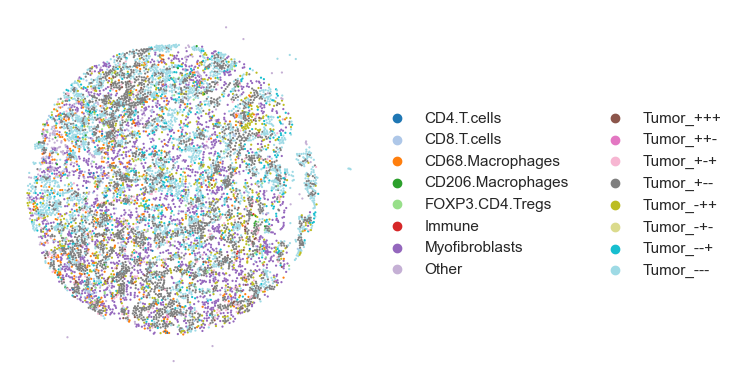

In [49]:
sc.pl.spatial(Scimap_count_adata_2B_Core_39, color='celltype_2', spot_size=20, title='', frameon=False, show=True, palette='tab20')

In [54]:
Scimap_count_adata_2B_Core_39 = sm.tl.spatial_distance (Scimap_count_adata_2B_Core_39, phenotype='celltype_2')

Processing Image: 2B


In [181]:
Scimap_count_adata_2B_Core_39 = sm.tl.spatial_distance (Scimap_count_adata_2B_Core_39, phenotype='Niches')

Processing Image: 2B


In [182]:
Scimap_count_adata_2B_Core_39.obs['Niches'].unique()

['Tumor_Rich', 'CD8.T.Cells_Rich', 'Myofibroblasts_Rich', 'Tumor_Stroma_Interface', 'M2_Macrophages_Rich', 'Other_Stroma_Rich', 'Tumor_NQO1+_Rich', 'Immune_Rich', 'Tumor_GCLC+VIM+_Rich', 'CD4.T.Cells_Rich']
Categories (10, object): ['CD4.T.Cells_Rich', 'CD8.T.Cells_Rich', 'Immune_Rich', 'M2_Macrophages_Rich', ..., 'Tumor_GCLC+VIM+_Rich', 'Tumor_NQO1+_Rich', 'Tumor_Rich', 'Tumor_Stroma_Interface']

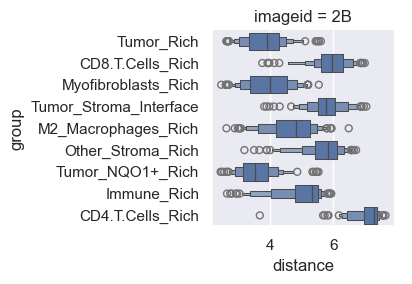

In [183]:
distance_to = ['Tumor_Rich', 'CD8.T.Cells_Rich', 'Myofibroblasts_Rich', 
               'Tumor_Stroma_Interface', 'M2_Macrophages_Rich', 'Other_Stroma_Rich', 
               'Tumor_NQO1+_Rich', 'Immune_Rich', 'CD4.T.Cells_Rich']

sm.pl.spatial_distance (Scimap_count_adata_2B_Core_39, phenotype='Niches', method='numeric',
                        distance_from='Tumor_GCLC+VIM+_Rich', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)

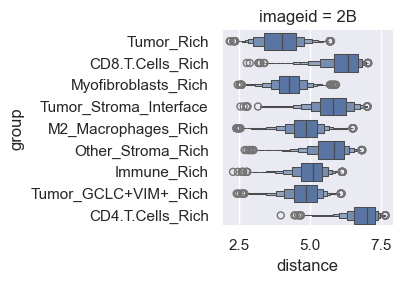

In [184]:
distance_to = ['Tumor_Rich', 'CD8.T.Cells_Rich', 'Myofibroblasts_Rich', 
               'Tumor_Stroma_Interface', 'M2_Macrophages_Rich', 'Other_Stroma_Rich', 
               'Immune_Rich', 'Tumor_GCLC+VIM+_Rich', 'CD4.T.Cells_Rich']

sm.pl.spatial_distance (Scimap_count_adata_2B_Core_39, phenotype='Niches', method='numeric',
                        distance_from='Tumor_NQO1+_Rich', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)

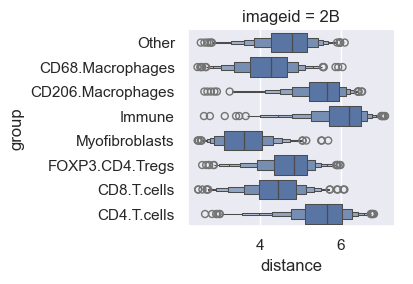

In [55]:
distance_to = ['Other', 'CD68.Macrophages', 'CD206.Macrophages', 'Immune', 'Myofibroblasts', 'FOXP3.CD4.Tregs', 'CD8.T.cells', 'CD4.T.cells']
sm.pl.spatial_distance (Scimap_count_adata_2B_Core_39, phenotype='celltype_2', method='numeric',
                        distance_from='Tumor_-++', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)

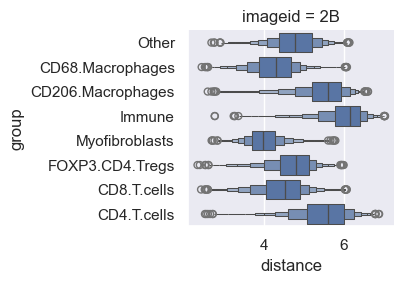

In [56]:
distance_to = ['Other', 'CD68.Macrophages', 'CD206.Macrophages', 'Immune', 'Myofibroblasts', 'FOXP3.CD4.Tregs', 'CD8.T.cells', 'CD4.T.cells']
sm.pl.spatial_distance (Scimap_count_adata_2B_Core_39, phenotype='celltype_2', method='numeric',
                        distance_from='Tumor_+--', distance_to=distance_to, 
                        log=True, height=3, aspect=11/8)

In [62]:
Scimap_count_adata_2B_Core_39 = sm.tl.spatial_interaction (Scimap_count_adata_2B_Core_39, 
                                  method='radius', phenotype='celltype_2',
                                  radius=45, 
                                  label='spatial_interaction_radius')

Processing Image: ['2B']
Categories (1, object): ['2B']
Identifying neighbours within 45 pixels of every cell
Mapping phenotype to neighbors
Performing 1000 permutations
Consolidating the permutation results


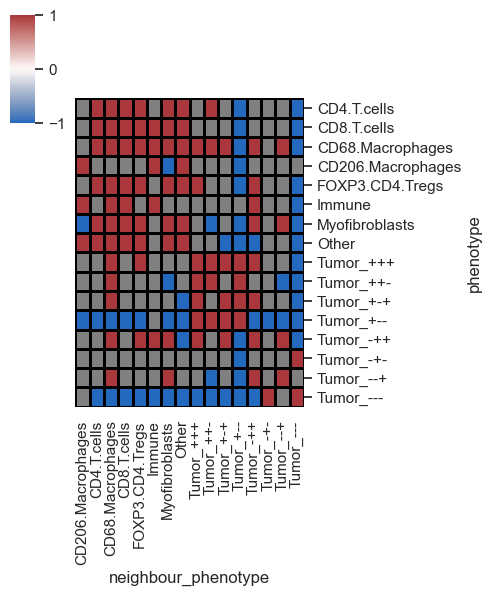

In [65]:
sm.pl.spatial_interaction(Scimap_count_adata_2B_Core_39, 
                          spatial_interaction='spatial_interaction_radius', binary_view=True,
                          linewidths=0.75, linecolor='black', figsize=(5,6))

# adata with tumor

In [7]:
adata_tumor = adata[(adata.obs['celltype'] == 'Tumor')]

In [8]:
Scimap_count_adata_tumor = sm.tl.spatial_count(adata_tumor, phenotype='NQO1_GCLC_VIM', method='radius', radius=45, label='spatial_count')
Scimap_count_adata_tumor = sm.tl.spatial_cluster(Scimap_count_adata_tumor, df_name='spatial_count', method='kmeans', k=25, label='spatial_count_kmeans')

Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell
Identifying neighbours within 45 pixels of every cell


/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/scimap/tools/spatial_count.py:203: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



Kmeans clustering


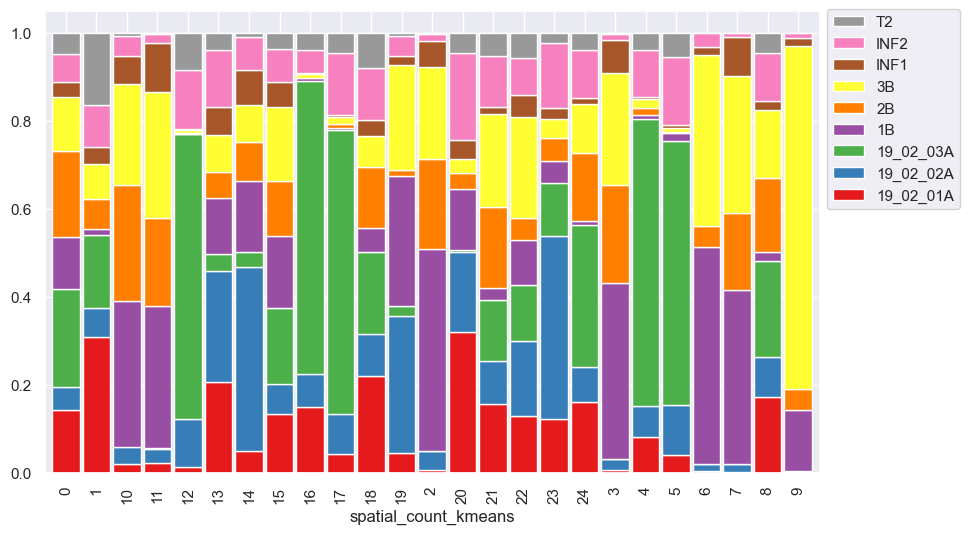

In [26]:
sm.pl.stacked_barplot (Scimap_count_adata_tumor, x_axis='spatial_count_kmeans', y_axis='imageid', figsize=(10, 6))

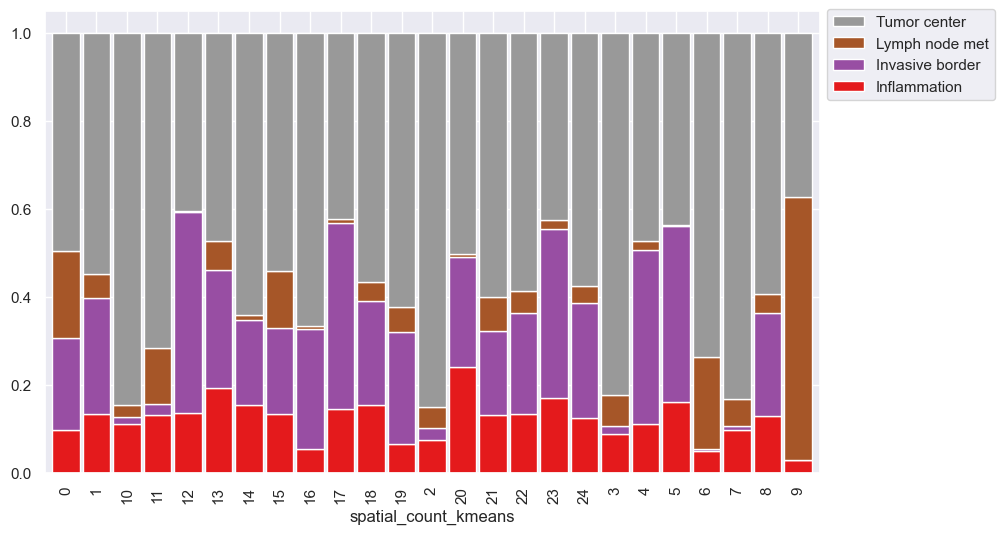

In [27]:
sm.pl.stacked_barplot (Scimap_count_adata_tumor, x_axis='spatial_count_kmeans', y_axis='Annotation', figsize=(10, 6))

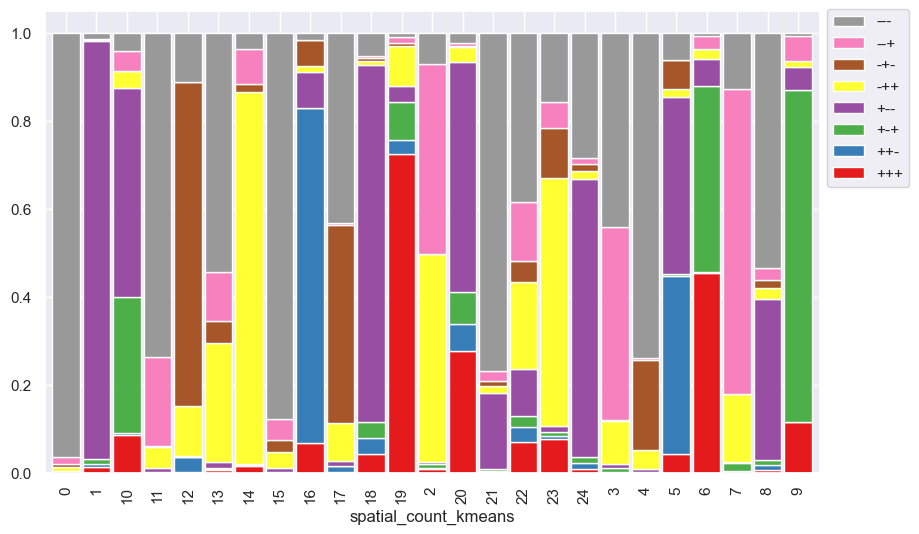

In [28]:
sm.pl.stacked_barplot (Scimap_count_adata_tumor, x_axis='spatial_count_kmeans', y_axis='NQO1_GCLC_VIM', figsize=(10, 6))

In [29]:
Scimap_count_adata_tumor.obs['spatial_count_kmeans'].value_counts()

spatial_count_kmeans
0     522956
15    192495
1     186702
18     82768
11     81840
4      56115
14     55106
3      55030
13     53152
7      51322
24     44598
21     44227
8      43017
2      38002
23     35535
19     32416
17     31593
16     30533
9      24386
5      23977
12     22868
6      19882
20     17410
10     16576
22     10654
Name: count, dtype: int64

## INF2

In [16]:
Scimap_count_adata_tumor_INF2 = Scimap_count_adata_tumor[(Scimap_count_adata_tumor.obs['imageid'] == 'INF2')]

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializi

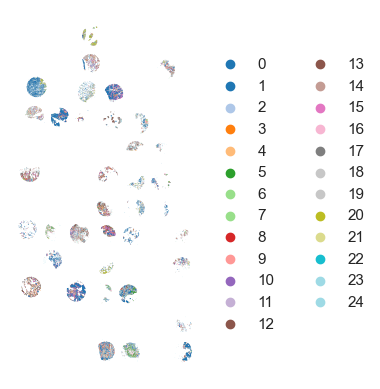

In [34]:
sc.pl.spatial(Scimap_count_adata_tumor_INF2, color='spatial_count_kmeans', spot_size=30, title='', frameon=False, show=True, palette='tab20')

In [17]:
Scimap_count_adata_tumor_INF2_Core_79 = Scimap_count_adata_tumor_INF2[Scimap_count_adata_tumor_INF2.obs['core_imageid'] == 'core79_INF2']

In [18]:
Scimap_count_adata_tumor_INF2_Core_79.obs

,X_centroid,Y_centroid,core_imageid,cores.x,celltype,Annotation,Stage,patient_id_AB19_1654,Area,Eccentricity,celltype.1,antioxidant_NQOI,antioxidant_GCLC,antioxidant_TXNRD1,antioxidant_GLUT1,NQO1_GCLC_VIM,CellID,imageid,spatial_count_kmeans
INF2_177068,5471.491,10200.41,core79_INF2,core79,Tumor,Inflammation,2,AB19-1654_P10601,340,0.813855,Tumor,failed_classify,failed_classify,failed_classify,GLUT1_pos,---,177068,INF2,24
INF2_177070,5479.929,10210.07,core79_INF2,core79,Tumor,Inflammation,2,AB19-1654_P10601,169,0.255912,Tumor,NQO1_pos,failed_classify,failed_classify,GLUT1_pos,+--,177070,INF2,8
INF2_177071,5493.954,10207.06,core79_INF2,core79,Tumor,Inflammation,2,AB19-1654_P10601,217,0.549014,Tumor,NQO1_pos,failed_classify,failed_classify,GLUT1_pos,+--,177071,INF2,8
INF2_177072,5544.870,10215.72,core79_INF2,core79,Tumor,Inflammation,2,AB19-1654_P10601,269,0.784027,Tumor,failed_classify,failed_classify,failed_classify,GLUT1_pos,---,177072,INF2,8
INF2_177073,5531.610,10213.47,core79_INF2,core79,Tumor,Inflammation,2,AB19-1654_P10601,118,0.873862,Tumor,NQO1_pos,failed_classify,failed_classify,GLUT1_pos,+--,177073,INF2,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INF2_281653,6356.045,12307.32,core79_INF2,core79,Tumor,Inflammation,2,AB19-1654_P10601,133,0.537541,Tumor,NQO1_pos,GCLC_pos,TXNRD1_pos,failed_classify,+++,281653,INF2,19
INF2_281656,6347.048,12313.61,core79_INF2,core79,Tumor,Inflammation,2,AB19-1654_P10601,145,0.467549,Tumor,NQO1_pos,GCLC_pos,TXNRD1_pos,failed_classify,+++,281656,INF2,19
INF2_281660,6363.582,12317.81,core79_INF2,core79,Tumor,Inflammation,2,AB19-1654_P10601,263,0.820115,Tumor,NQO1_pos,GCLC_pos,TXNRD1_pos,failed_classify,+++,281660,INF2,19
INF2_281669,6328.246,12320.76,core79_INF2,core79,Tumor,Inflammation,2,AB19-1654_P10601,264,0.648284,Tumor,failed_classify,GCLC_pos,TXNRD1_pos,failed_classify,-++,281669,INF2,19


/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/scanpy/plotting/_utils.py:471: ImplicitModificationWarning:

Trying to modify attribute `._uns` of view, initializing view as actual.



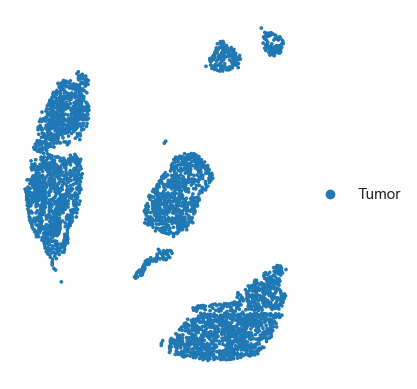

In [36]:
sc.pl.spatial(Scimap_count_adata_tumor_INF2_Core_79, color='celltype', spot_size=30, title='', frameon=False, show=True, palette='tab20')

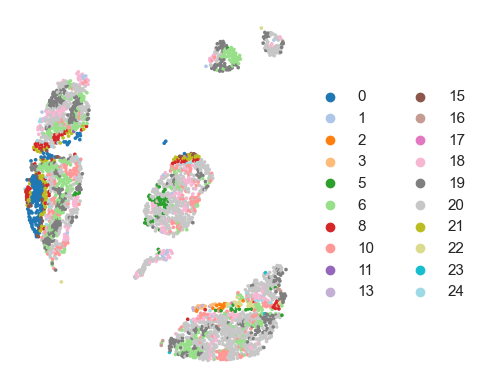

In [37]:
sc.pl.spatial(Scimap_count_adata_tumor_INF2_Core_79, color='spatial_count_kmeans', spot_size=30, title='', frameon=False, show=True, palette='tab20')

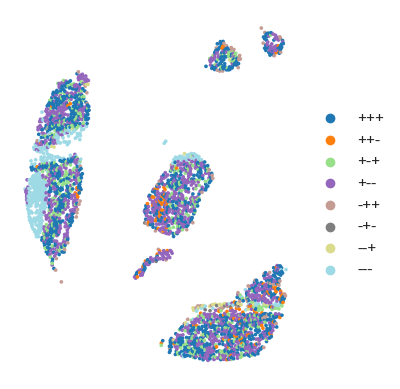

In [38]:
sc.pl.spatial(Scimap_count_adata_tumor_INF2_Core_79, color='NQO1_GCLC_VIM', spot_size=30, title='', frameon=False, show=True, palette='tab20')

## 2B

In [9]:
Scimap_count_adata_tumor_2B = Scimap_count_adata_tumor[(Scimap_count_adata_tumor.obs['imageid'] == '2B')]

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializi

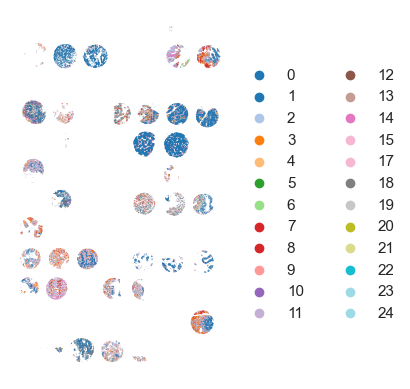

In [40]:
sc.pl.spatial(Scimap_count_adata_tumor_2B, color='spatial_count_kmeans', spot_size=30, title='', frameon=False, show=True, palette='tab20')

### Core 15

In [20]:
Scimap_count_adata_tumor_2B_Core_15 = Scimap_count_adata_tumor_2B[Scimap_count_adata_tumor_2B.obs['core_imageid'] == 'core15_2B']

In [21]:
Scimap_count_adata_tumor_2B_Core_15.obs

,X_centroid,Y_centroid,core_imageid,cores.x,celltype,Annotation,Stage,patient_id_AB19_1654,Area,Eccentricity,celltype.1,antioxidant_NQOI,antioxidant_GCLC,antioxidant_TXNRD1,antioxidant_GLUT1,NQO1_GCLC_VIM,CellID,imageid,spatial_count_kmeans
2B_135944,36248.89,6148.492,core15_2B,core15,Tumor,Tumor center,2,AB19-1654_P10575,185,0.623643,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,--+,135944,2B,7
2B_135945,36494.52,6149.749,core15_2B,core15,Tumor,Tumor center,2,AB19-1654_P10575,311,0.427847,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,--+,135945,2B,2
2B_135946,36330.58,6153.418,core15_2B,core15,Tumor,Tumor center,2,AB19-1654_P10575,287,0.791225,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,--+,135946,2B,7
2B_135947,36402.97,6154.357,core15_2B,core15,Tumor,Tumor center,2,AB19-1654_P10575,544,0.739953,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,--+,135947,2B,7
2B_135948,36744.59,6151.212,core15_2B,core15,Tumor,Tumor center,2,AB19-1654_P10575,241,0.621816,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,--+,135948,2B,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2B_94616,37356.10,6148.620,core15_2B,core15,Tumor,Tumor center,2,AB19-1654_P10575,403,0.808690,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,--+,94616,2B,7
2B_94617,37212.72,6150.651,core15_2B,core15,Tumor,Tumor center,2,AB19-1654_P10575,367,0.621273,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,--+,94617,2B,7
2B_94618,38009.39,6144.892,core15_2B,core15,Tumor,Tumor center,2,AB19-1654_P10575,148,0.672956,Tumor,failed_classify,GCLC_pos,failed_classify,failed_classify,-++,94618,2B,14
2B_94622,37098.85,6150.167,core15_2B,core15,Tumor,Tumor center,2,AB19-1654_P10575,371,0.557217,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,--+,94622,2B,7


/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



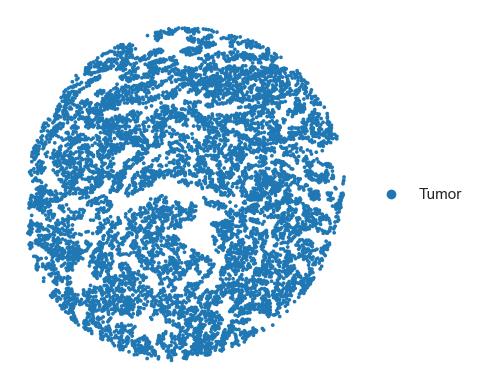

In [42]:
sc.pl.spatial(Scimap_count_adata_tumor_2B_Core_15, color='celltype', spot_size=30, title='', frameon=False, show=True, palette='tab20')

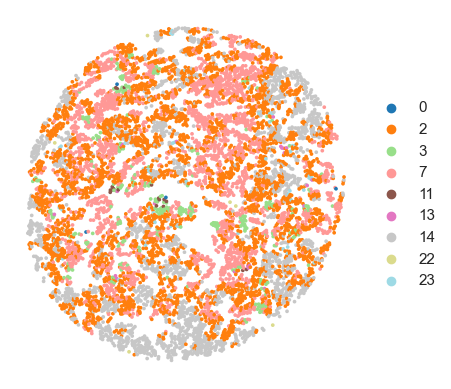

In [43]:
sc.pl.spatial(Scimap_count_adata_tumor_2B_Core_15, color='spatial_count_kmeans', spot_size=30, title='', frameon=False, show=True, palette='tab20')

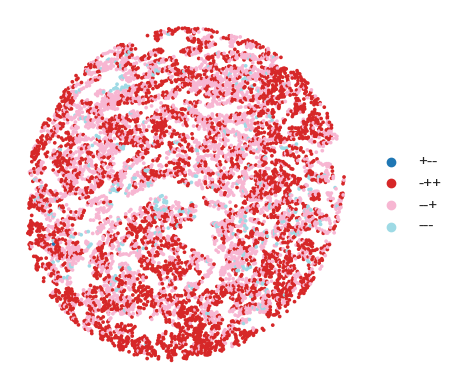

In [44]:
sc.pl.spatial(Scimap_count_adata_tumor_2B_Core_15, color='NQO1_GCLC_VIM', spot_size=30, title='', frameon=False, show=True, palette='tab20')

### Core 39

In [22]:
Scimap_count_adata_tumor_2B_Core_39 = Scimap_count_adata_tumor_2B[Scimap_count_adata_tumor_2B.obs['core_imageid'] == 'core39_2B']

In [23]:
Scimap_count_adata_tumor_2B_Core_39.obs

,X_centroid,Y_centroid,core_imageid,cores.x,celltype,Annotation,Stage,patient_id_AB19_1654,Area,Eccentricity,celltype.1,antioxidant_NQOI,antioxidant_GCLC,antioxidant_TXNRD1,antioxidant_GLUT1,NQO1_GCLC_VIM,CellID,imageid,spatial_count_kmeans
2B_336028,26539.34,16178.26,core39_2B,core39,Tumor,Tumor center,2,AB19-1654_P10587,311,0.752241,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,336028,2B,0
2B_336029,26552.33,16185.35,core39_2B,core39,Tumor,Tumor center,2,AB19-1654_P10587,234,0.598148,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,336029,2B,0
2B_336030,26413.74,16196.13,core39_2B,core39,Tumor,Tumor center,2,AB19-1654_P10587,714,0.645622,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,336030,2B,0
2B_336031,26394.29,16193.88,core39_2B,core39,Tumor,Tumor center,2,AB19-1654_P10587,436,0.801651,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,336031,2B,15
2B_336032,26376.70,16193.10,core39_2B,core39,Tumor,Tumor center,2,AB19-1654_P10587,320,0.717255,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,336032,2B,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2B_457618,26728.79,18746.82,core39_2B,core39,Tumor,Tumor center,2,AB19-1654_P10587,267,0.687899,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,457618,2B,8
2B_457619,26672.71,18746.73,core39_2B,core39,Tumor,Tumor center,2,AB19-1654_P10587,190,0.856983,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,457619,2B,8
2B_457620,26919.62,18749.54,core39_2B,core39,Tumor,Tumor center,2,AB19-1654_P10587,269,0.655362,Tumor,failed_classify,GCLC_pos,failed_classify,failed_classify,-++,457620,2B,0
2B_457621,26677.43,18758.35,core39_2B,core39,Tumor,Tumor center,2,AB19-1654_P10587,389,0.806209,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,457621,2B,8


/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



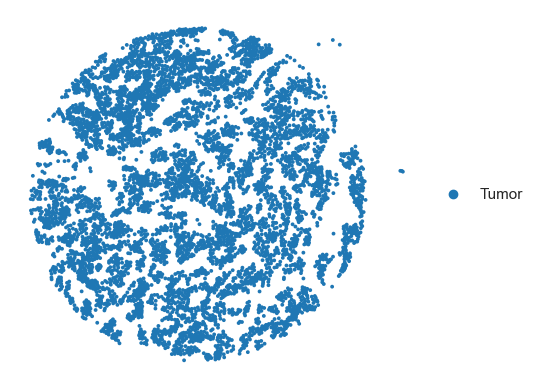

In [46]:
sc.pl.spatial(Scimap_count_adata_tumor_2B_Core_39, color='celltype', spot_size=30, title='', frameon=False, show=True, palette='tab20')

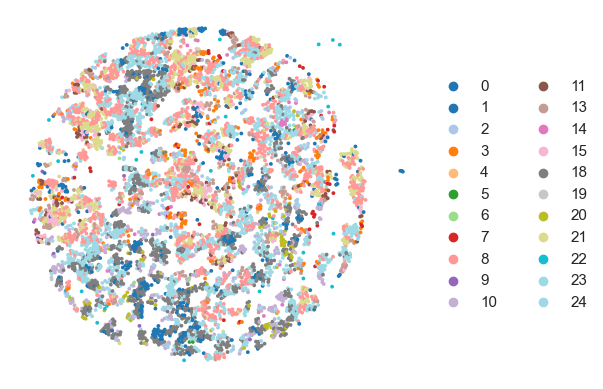

In [47]:
sc.pl.spatial(Scimap_count_adata_tumor_2B_Core_39, color='spatial_count_kmeans', spot_size=30, title='', frameon=False, show=True, palette='tab20')

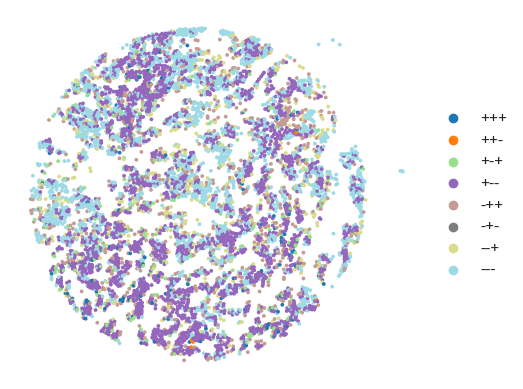

In [48]:
sc.pl.spatial(Scimap_count_adata_tumor_2B_Core_39, color='NQO1_GCLC_VIM', spot_size=30, title='', frameon=False, show=True, palette='tab20')

### Core26

In [10]:
Scimap_count_adata_tumor_2B_Core_26 = Scimap_count_adata_tumor_2B[Scimap_count_adata_tumor_2B.obs['core_imageid'] == 'core26_2B']

In [24]:
Scimap_count_adata_tumor_2B_Core_26.obs

,X_centroid,Y_centroid,core_imageid,cores.x,celltype,Annotation,Stage,patient_id_AB19_1654,Area,Eccentricity,celltype.1,antioxidant_NQOI,antioxidant_GCLC,antioxidant_TXNRD1,antioxidant_GLUT1,NQO1_GCLC_VIM,CellID,imageid,spatial_count_kmeans
2B_458820,34055.10,19599.34,core26_2B,core26,Tumor,Tumor center,2,AB19-1654_P10580,337,0.606929,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,--+,458820,2B,0
2B_458822,33973.55,19599.42,core26_2B,core26,Tumor,Tumor center,2,AB19-1654_P10580,325,0.584354,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,458822,2B,0
2B_458823,33994.03,19607.18,core26_2B,core26,Tumor,Tumor center,2,AB19-1654_P10580,621,0.576722,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,458823,2B,0
2B_458825,34029.94,19599.42,core26_2B,core26,Tumor,Tumor center,2,AB19-1654_P10580,236,0.650886,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,458825,2B,15
2B_458827,34041.18,19604.13,core26_2B,core26,Tumor,Tumor center,2,AB19-1654_P10580,188,0.866007,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,458827,2B,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2B_540995,34915.99,21572.13,core26_2B,core26,Tumor,Tumor center,2,AB19-1654_P10580,260,0.690006,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,--+,540995,2B,0
2B_541001,34881.90,21585.10,core26_2B,core26,Tumor,Tumor center,2,AB19-1654_P10580,371,0.726983,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,541001,2B,11
2B_541002,34869.42,21579.51,core26_2B,core26,Tumor,Tumor center,2,AB19-1654_P10580,115,0.684505,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,---,541002,2B,15
2B_541003,34863.51,21591.85,core26_2B,core26,Tumor,Tumor center,2,AB19-1654_P10580,247,0.582505,Tumor,failed_classify,failed_classify,failed_classify,failed_classify,--+,541003,2B,0


/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.

/Users/chen/opt/anaconda3/envs/napari-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1209: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializi

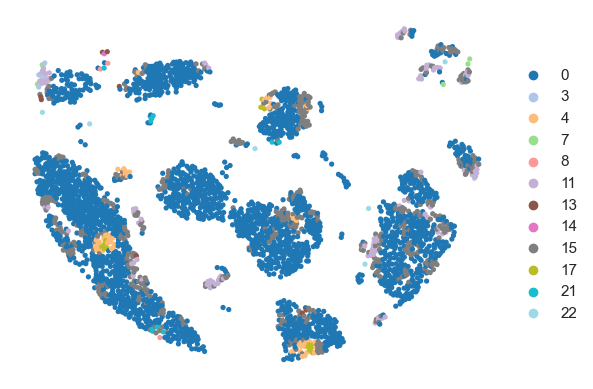

In [11]:
sc.pl.spatial(Scimap_count_adata_tumor_2B_Core_26, color='spatial_count_kmeans', spot_size=30, title='', frameon=False, show=True, palette='tab20')

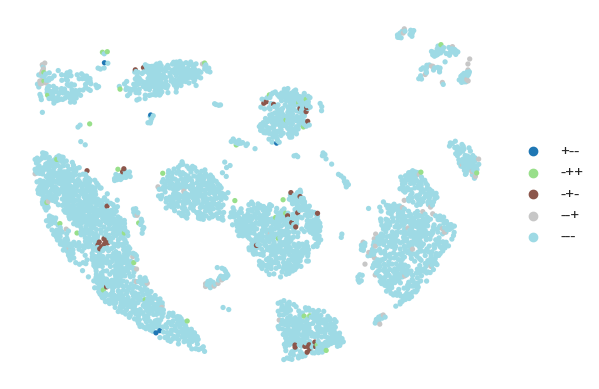

In [12]:
sc.pl.spatial(Scimap_count_adata_tumor_2B_Core_26, color='NQO1_GCLC_VIM', spot_size=30, title='', frameon=False, show=True, palette='tab20')